In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap
import scipy.stats as st
from scipy.stats import norm

C:\Users\Carlos\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Funções

#função tratar nulos
def tratarNulos(dados):
    dataset = dados.copy()  # evita problemas de referência
    
    # Colunas numéricas que representam categorias
    colunas_categoricas_numericas = [
        'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
        'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
        'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC','Q001','Q002','Q003','Q004','Q005','Q006',
        'Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025'
    ]
    
    for col in dataset.columns:
        if dataset[col].isnull().any():  # só trata se houver nulos
            if col in colunas_categoricas_numericas:
                # Para categóricas → moda
                moda = dataset[col].mode()
                if not moda.empty:
                    dataset[col] = dataset[col].fillna(moda.iloc[0])
            else:
                # Para numéricas contínuas → média
                media = dataset[col].mean()
                dataset[col] = dataset[col].fillna(media)
    
    return dataset



#Função analisar importância das features de forma agregada
def analisar_importancia_features_agregada(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância das features de um modelo DecisionTreeClassifier,
    somando as importâncias das dummies das features categóricas.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - categoricas: lista de colunas categóricas originais
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_agregado: DataFrame com importância agregada por feature
    """

    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    # Extrair nomes das features pós-transformação
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    
    # Importâncias
    importances = clf.feature_importances_
    
    # Criar DataFrame
    df = pd.DataFrame({
        'feature_expandida': nomes_features,
        'importancia': importances
    })
    
    # Inicializar coluna de feature original
    df['feature_original'] = df['feature_expandida']
    
    # Mapear dummies categóricas para a feature original
    for cat in categoricas:
        mask = df['feature_expandida'].str.contains(f"__{cat}_")
        df.loc[mask, 'feature_original'] = cat
    
    # Agregar importâncias por feature original
    df_agregado = df.groupby('feature_original')['importancia'].sum().sort_values(ascending=False)
    # 🔧 REMOVER PREFIXO "num_"
    df_agregado.index = df_agregado.index.str.replace(r'^.*__', '', regex=True)
    
    # Filtrar top_n se necessário
    if top_n:
        df_agregado = df_agregado.head(top_n)
    
    # Print em texto
    print("Importância das features (agregada):")
    for feat, imp in df_agregado.items():
        print(f"Feature {feat}: {imp:.4f}")
    
    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_agregado.index, df_agregado.values)   # <-- barras horizontais
    plt.xlabel("Importância")                         # título do eixo X
    plt.ylabel("Features")                            # título do eixo Y
    plt.title(f"Importância das Features {titulo}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return df_agregado


#Função analisar features de forma individual
def analisar_importancia_features(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância individual das features (sem agregação) 
    de um modelo DecisionTreeClassifier treinado dentro de um pipeline.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_importancias: DataFrame com importâncias individuais
    """

    # Extrair nomes das features após o pré-processamento
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    # 🔧 REMOVER prefixos do ColumnTransformer (cat__, num__, etc.)
    nomes_features = pd.Series(nomes_features).str.replace(r'^.*__', '', regex=True).values

    # Pegar as importâncias
    importances = clf.feature_importances_

    # Criar DataFrame
    df_importancias = pd.DataFrame({
        'feature': nomes_features,
        'importancia': importances
    }).sort_values(by='importancia', ascending=False)

    # Filtrar top_n se solicitado
    if top_n:
        df_importancias = df_importancias.head(top_n)

    # Print simples
    print("Importância das features (sem agregação):")
    for feat, imp in zip(df_importancias['feature'], df_importancias['importancia']):
        print(f"{feat}: {imp:.4f}")

    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_importancias['feature'], df_importancias['importancia'])
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.title(f"Importância Individual das Features {titulo}")
    plt.gca().invert_yaxis()  # deixa a mais importante no topo
    plt.tight_layout()
    plt.show()

    return df_importancias


#Função analisar desempenhos estatísticos(media, mediana, desvio padrão, quartis, valor minimo, valor maximo, amplitude e coeficiente de variação) pra cada classe de renda social
def analisar_desempenho_por_classe(
    dataset, 
    nome_dataset, 
    notas=['NU_NOTA_CH','NU_NOTA_CN','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO'],
    nivel_confianca=0.95
):
    """
    Analisa estatísticas das notas por classe social utilizando a distribuição t de Student
    para o cálculo do Intervalo de Confiança da média.
    """
    
    # 1. Preparação dos dados
    df = dataset.copy()
    df['media_notas'] = df[notas].mean(axis=1)

    # 2. Definição das funções de agregação
    def calc_ic_t(coluna):

        if len(coluna) < 2: return np.nan, np.nan
        return st.t.interval(nivel_confianca, len(coluna)-1, loc=coluna.mean(), scale=coluna.sem())

    # 3. Agrupamento e Estatísticas Descritivas
    resumo = df.groupby('faixa_renda')['media_notas'].agg(
        media='mean',
        mediana='median',
        desvio_padrao='std',
        n='count',
        variancia='var',
        q1=lambda x: np.percentile(x, 25),
        q3=lambda x: np.percentile(x, 75),
        valor_minimo='min',
        valor_maximo='max',
        amplitude=lambda x: x.max() - x.min(),
        coef_var=lambda x: (x.std() / x.mean() * 100) if x.mean() != 0 else np.nan
    ).reset_index()

    # 4. Cálculo do Intervalo de Confiança
    # Aplicando a função st.t.interval para cada grupo
    ics = df.groupby('faixa_renda')['media_notas'].apply(calc_ic_t)
    resumo['ic_inf'] = resumo['faixa_renda'].map(lambda x: ics[x][0])
    resumo['ic_sup'] = resumo['faixa_renda'].map(lambda x: ics[x][1])

    # 5. Ordenação das Classes
    ordem_classes = {
        "Até 2 salários mínimos": 1,
        "De 2 a 3 salários mínimos": 2,
        "De 3 a 6 salários mínimos": 3,
        "De 6 a 10 salários mínimos": 4,
        "De 10 a 15 salários mínimos": 5,
        "Acima de 15 salários mínimos": 6
    }
    
    resumo['ordem'] = resumo['faixa_renda'].apply(
        lambda x: next((v for k, v in ordem_classes.items() if k in x), 99)
    )
    resumo = resumo.sort_values('ordem').drop(columns='ordem')

    # 6. Visualização
    plt.figure(figsize=(12, 7))
    
    # Criar lista de dados para o boxplot mantendo a ordem do resumo
    dados_plot = [df[df['faixa_renda'] == classe]['media_notas'].dropna() for classe in resumo['faixa_renda']]

    # Boxplot base
    plt.boxplot(
        dados_plot,
        vert=False,
        labels=resumo['faixa_renda'],
        showfliers=True, 
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='blue', alpha=0.5)
    )

    # Sobreposição do Intervalo de Confiança (Método t-Student)
    y_pos = np.arange(1, len(resumo) + 1)
    
    plt.hlines(
        y=y_pos,
        xmin=resumo['ic_inf'],
        xmax=resumo['ic_sup'],
        colors='red',
        linewidth=4,
        label=f'IC {int(nivel_confianca*100)}% (t-Student)'
    )

    # Ponto da média
    plt.plot(resumo['media'], y_pos, 'ro', markersize=8, label='Média')

    plt.xlabel("Nota Média")
    plt.ylabel("Faixa de Renda Familiar")
    plt.title(f"Desempenho por Classe Social: {nome_dataset}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

    return resumo


def shap_multiclasses(df_transformado, clf, ano):
    
    amostra = df_transformado.sample(200, random_state=42)
    # compute SHAP values
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(amostra)
    class_names = [
    'Até 2 salários mínimos',
    'De 2 a 3 salários mínimos',
    'De 3 a 6 salários mínimos',
    'De 6 a 10 salários mínimos',
    'De 10 a 15 salários mínimos',
    'Acima de 15 salários mínimos'
    ]
    shap.summary_plot(shap_values, amostra.values, plot_type="bar", class_names= class_names, class_inds=list(range(len(class_names))), feature_names= amostra.columns, show=False)

    # Título centralizado na FIGURA inteira
    plt.suptitle(
    f"Importância das variáveis por faixa de renda {ano}",
    fontsize=14,
    y=0.98
    )

    # Ajusta margens para acomodar nomes das features
    plt.subplots_adjust(left=0.32, top=0.92)

    plt.show()

    

#Função criação do modelo, clf, preprocessador
def treinar_modelo(dataset):

    # 1. Separar X e y
    X = dataset.drop(columns=['faixa_renda'])
    y = dataset['faixa_renda']

    # 2. Identificar colunas categóricas e numéricas
    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    numericas = ['Q005','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC',
                'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_FAIXA_ETARIA', 'TP_ANO_CONCLUIU'] 

    # 3. Pré-processamento (OneHot para categóricas, passthrough para numéricas)
    preprocessador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
            ('num', 'passthrough', numericas)
        ]
    )

    clf = DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=None,          # sem limite de profundidade
        min_samples_split=2,     # pode dividir até com 2 amostras
        min_samples_leaf=1,      # folhas com 1 amostra
        max_features=None,       # usa todos os atributos
        random_state=42
    )

    # 4. Criar pipeline com pré-processamento + modelo
    modelo = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador', clf) 
    ])



    # 6. Treinar modelo
    modelo.fit(X, y)

    # 7. Avaliar
    y_pred = modelo.predict(X)
    print("Acurácia:", accuracy_score(y, y_pred))
    print("\nRelatório de classificação:\n", classification_report(y, y_pred))
    print("\nMatriz de confusão:\n", confusion_matrix(y, y_pred))

     # 👇 Aqui ocorre a transformação usando o preprocessador já treinado
    X_transformado = modelo.named_steps['preprocessador'].transform(X)

    # 👇 Recuperando os nomes das colunas após OneHotEncoding
    ohe = modelo.named_steps['preprocessador'].named_transformers_['cat']
    nomes_ohe = list(ohe.get_feature_names_out(categoricas))

    # Combine OHE + numéricas
    colunas_final = nomes_ohe + numericas 

    # Convertendo para DataFrame final
    df_transformado = pd.DataFrame(X_transformado, columns=colunas_final)

    return modelo, clf, df_transformado

In [3]:
caminho_arquivo = './dados/MICRODADOS_ENEM_2019.csv'
data = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')
num_columns = data.shape[1]
num_rows = data.shape[0]
print(f"Número de colunas: {num_columns}")
print(f"Número de linhas: {num_rows}")
data.head()

Número de colunas: 76
Número de linhas: 5095171


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,190001595656,2019,13,M,1,3,1,1,11,1,...,A,A,A,A,A,A,C,A,C,B
1,190001421546,2019,8,M,1,1,1,1,5,1,...,A,A,A,B,A,A,E,A,A,B
2,190001133210,2019,13,F,1,3,1,1,13,1,...,A,A,A,B,A,A,C,A,A,B
3,190001199383,2019,10,F,1,1,1,1,4,1,...,A,A,A,C,A,B,D,A,B,B
4,190001237802,2019,7,F,1,1,1,1,4,1,...,B,A,A,B,A,A,C,B,B,B


In [4]:
dados_selecionados = data[['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001','Q002','Q003','Q004','Q005','Q006', 'Q007','Q008','Q009','Q010','Q011',
                       'Q012','Q013','Q014','Q015','Q016',
                       'Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025']]

In [5]:
print("Antes:")
print(dados_selecionados.isnull().sum()[data.isnull().sum() > 0])
dataset_sem_nulos  = tratarNulos(dados_selecionados)
print("\nDepois:")
print(dataset_sem_nulos.isnull().sum()[dataset_sem_nulos.isnull().sum() > 0])

Antes:
TP_ENSINO             2217036
TP_LOCALIZACAO_ESC    3947784
NU_NOTA_CN            1384836
NU_NOTA_CH            1172125
NU_NOTA_LC            1172125
NU_NOTA_MT            1384836
NU_NOTA_REDACAO       1172126
dtype: int64

Depois:
Series([], dtype: int64)


In [6]:
# Dicionário para mapear as respostas da questão Q006 (faixa de renda) em faixa de renda
mapa_renda = {
    'A': 'Até 2 salários mínimos',
    'B': 'Até 2 salários mínimos',
    'C': 'Até 2 salários mínimos',
    'D': 'Até 2 salários mínimos',
    'E': 'De 2 a 3 salários mínimos',
    'F': 'De 3 a 6 salários mínimos',
    'G': 'De 3 a 6 salários mínimos',
    'H': 'De 3 a 6 salários mínimos',
    'I': 'De 3 a 6 salários mínimos',
    'J': 'De 3 a 6 salários mínimos',
    'K': 'De 6 a 10 salários mínimos',
    'L': 'De 6 a 10 salários mínimos',
    'M': 'De 6 a 10 salários mínimos',
    'N': 'De 6 a 10 salários mínimos',
    'O': 'De 10 a 15 salários mínimos',
    'P': 'De 10 a 15 salários mínimos',
    'Q': 'Acima de 15 salários mínimos'
}

# Criar nova coluna 'faixa_renda' baseada na resposta da questão Q006
dataset_sem_nulos['faixa_renda'] = dataset_sem_nulos['Q006'].map(mapa_renda)
dataset_sem_nulos = dataset_sem_nulos.drop(columns=['Q006'])

In [7]:
modelo, clf, df_transformado = treinar_modelo(dataset_sem_nulos)

Acurácia: 0.9999199241791885

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     57149
      Até 2 salários mínimos       1.00      1.00      1.00   3316350
 De 10 a 15 salários mínimos       1.00      1.00      1.00     93455
   De 2 a 3 salários mínimos       1.00      1.00      1.00    475554
   De 3 a 6 salários mínimos       1.00      1.00      1.00    945505
  De 6 a 10 salários mínimos       1.00      1.00      1.00    207158

                    accuracy                           1.00   5095171
                   macro avg       1.00      1.00      1.00   5095171
                weighted avg       1.00      1.00      1.00   5095171


Matriz de confusão:
 [[  57149       0       0       0       0       0]
 [      0 3316348       0       1       1       0]
 [      0       0   93455       0       0       0]
 [      0     249       0  475305       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1530
Feature NU_NOTA_MT: 0.0631
Feature NU_NOTA_CH: 0.0593
Feature NU_NOTA_LC: 0.0592
Feature NU_NOTA_CN: 0.0573
Feature NU_NOTA_REDACAO: 0.0428
Feature Q008: 0.0392
Feature Q001: 0.0391
Feature Q004: 0.0366
Feature Q003: 0.0359
Feature Q002: 0.0356
Feature TP_FAIXA_ETARIA: 0.0338
Feature Q024: 0.0332
Feature Q005: 0.0277
Feature TP_ANO_CONCLUIU: 0.0241
Feature Q019: 0.0220
Feature Q009: 0.0215
Feature TP_COR_RACA: 0.0198
Feature Q022: 0.0198
Feature Q013: 0.0154


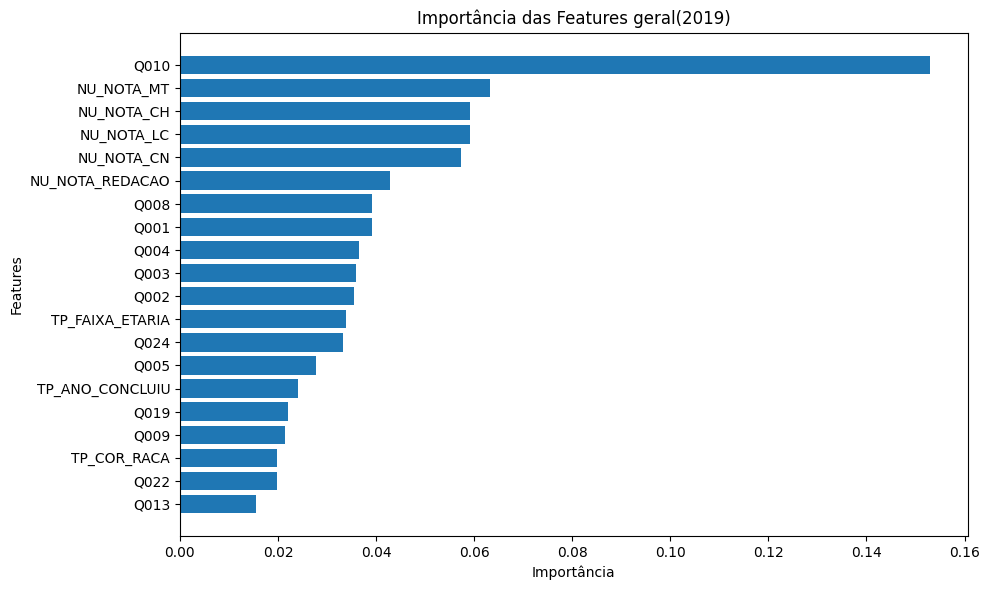

In [8]:
df_importancia = analisar_importancia_features_agregada(modelo, clf, "geral(2019)", 20)


Importância das features (sem agregação):
Q010_A: 0.1464
NU_NOTA_MT: 0.0631
NU_NOTA_CH: 0.0593
NU_NOTA_LC: 0.0592
NU_NOTA_CN: 0.0573
NU_NOTA_REDACAO: 0.0428
TP_FAIXA_ETARIA: 0.0338
Q008_B: 0.0319
Q005: 0.0277
TP_ANO_CONCLUIU: 0.0241
Q024_A: 0.0230
TP_COR_RACA: 0.0198
Q004_D: 0.0162
Q007_A: 0.0121
Q003_E: 0.0092
Q003_D: 0.0089
Q014_A: 0.0089
TP_ESTADO_CIVIL: 0.0087
TP_ESCOLA: 0.0083
Q021_A: 0.0079


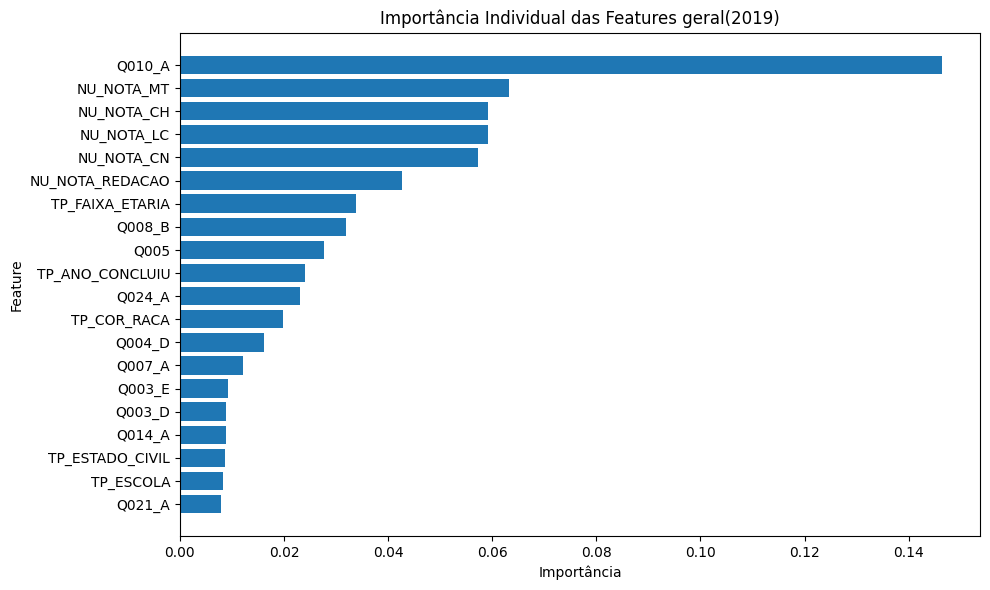

In [9]:
df_importancias_individuais = analisar_importancia_features(modelo, clf, "geral(2019)", top_n=20)


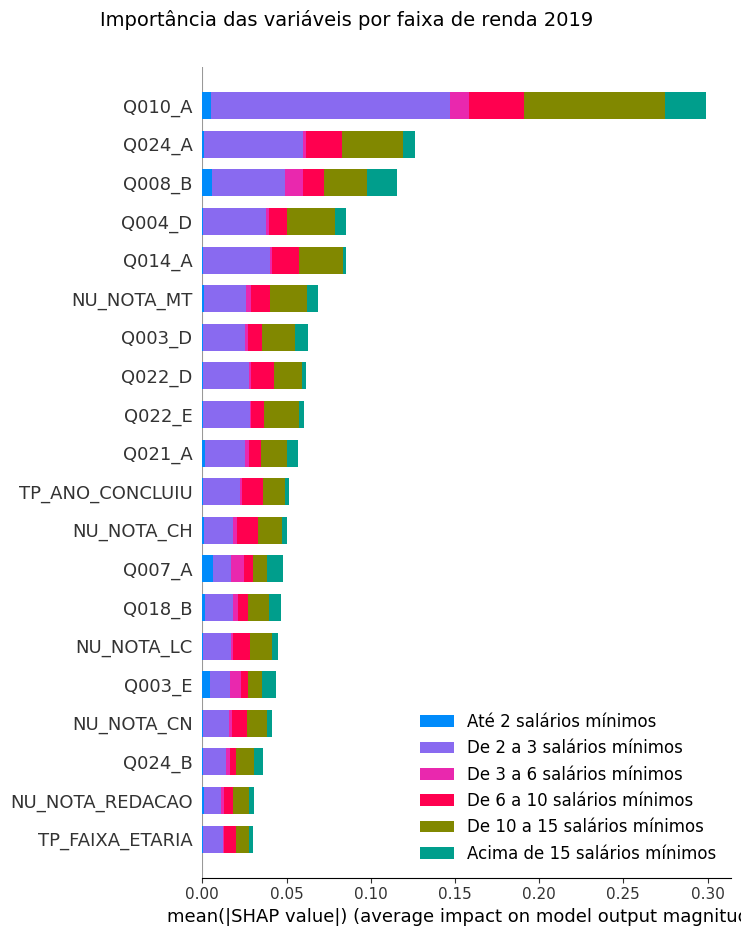

In [11]:
shap_multiclasses(df_transformado, clf, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


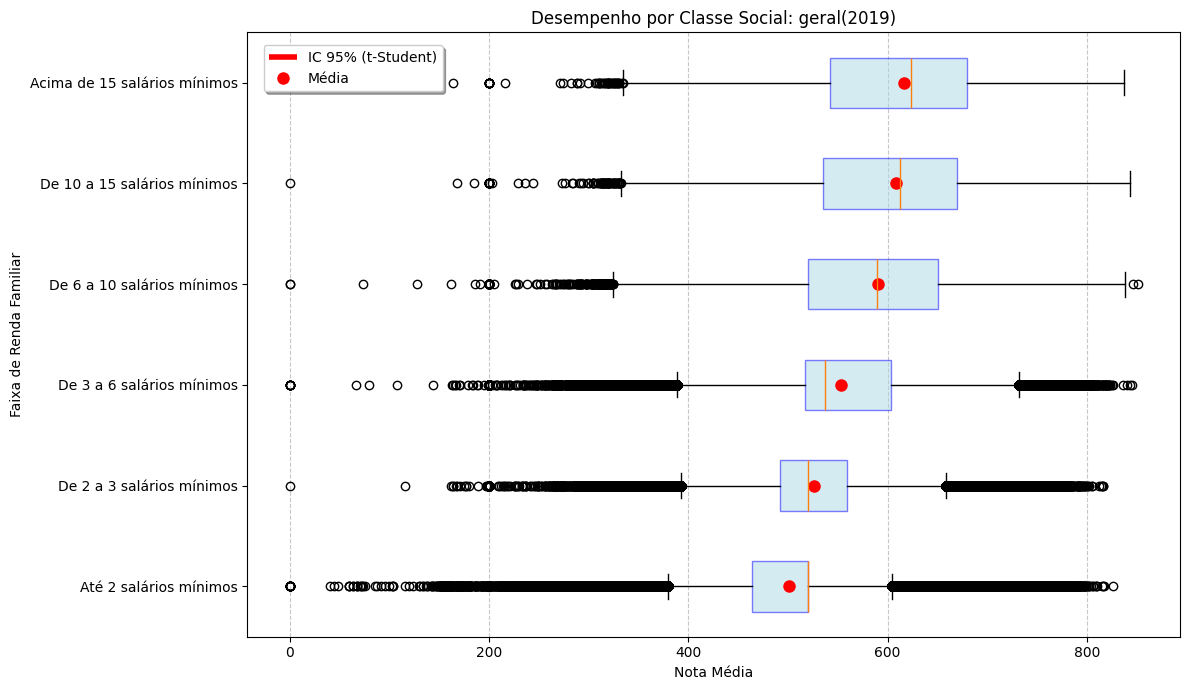

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,501.009225,519.979717,62.699234,3316350,3931.193921,463.680000,519.979717,0.0,826.30,826.30,12.514587,500.941745,501.076706
3,De 2 a 3 salários mínimos,526.035781,519.979717,66.035197,475554,4360.647299,492.322383,558.760000,0.0,816.18,816.18,12.553366,525.848098,526.223464
4,De 3 a 6 salários mínimos,553.466943,537.129533,75.024345,945505,5628.652285,517.320000,603.020000,0.0,845.00,845.00,13.555343,553.315719,553.618166
5,De 6 a 10 salários mínimos,590.439163,589.680000,79.938222,207158,6390.119278,519.979717,650.420000,0.0,850.82,850.82,13.538774,590.094929,590.783398
2,De 10 a 15 salários mínimos,608.304717,612.600000,80.769178,93455,6523.660042,534.930000,670.020000,0.0,842.70,842.70,13.277750,607.786874,608.822560
0,Acima de 15 salários mínimos,616.566036,623.880000,82.143034,57149,6747.478027,541.749533,679.980000,0.0,837.48,837.48,13.322666,615.892558,617.239515


In [7]:
analisar_desempenho_por_classe(dataset_sem_nulos, "geral(2019)")

In [8]:
# Filtrar apenas homens
dataset_homem = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "M"]  
num_columns = dataset_homem.shape[1]
num_rows = dataset_homem.shape[0]
print(f"Número de colunas dataset homem: {num_columns}")
print(f"Número de linhas dataset homem: {num_rows}")

# Filtrar apenas mulheres
dataset_mulher = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "F"]
num_columns = dataset_mulher.shape[1]
num_rows = dataset_mulher.shape[0]
print(f"Número de colunas dataset mulher: {num_columns}")
print(f"Número de linhas dataset mulher: {num_rows}")

Número de colunas dataset homem: 40
Número de linhas dataset homem: 2063411
Número de colunas dataset mulher: 40
Número de linhas dataset mulher: 3031760


In [14]:
modelo_homem, clf_homem, df_transformado_homem = treinar_modelo(dataset_homem)

Acurácia: 0.9999374821593953

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     30053
      Até 2 salários mínimos       1.00      1.00      1.00   1239805
 De 10 a 15 salários mínimos       1.00      1.00      1.00     46414
   De 2 a 3 salários mínimos       1.00      1.00      1.00    207039
   De 3 a 6 salários mínimos       1.00      1.00      1.00    440525
  De 6 a 10 salários mínimos       1.00      1.00      1.00     99575

                    accuracy                           1.00   2063411
                   macro avg       1.00      1.00      1.00   2063411
                weighted avg       1.00      1.00      1.00   2063411


Matriz de confusão:
 [[  30053       0       0       0       0       0]
 [      0 1239805       0       0       0       0]
 [      0       0   46414       0       0       0]
 [      0      69       0  206970       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1469
Feature NU_NOTA_MT: 0.0625
Feature NU_NOTA_CH: 0.0585
Feature NU_NOTA_LC: 0.0584
Feature NU_NOTA_CN: 0.0568
Feature NU_NOTA_REDACAO: 0.0436
Feature Q001: 0.0418
Feature Q003: 0.0378
Feature Q002: 0.0376
Feature Q008: 0.0362
Feature Q004: 0.0362
Feature TP_FAIXA_ETARIA: 0.0356
Feature Q024: 0.0336
Feature Q005: 0.0284
Feature TP_ANO_CONCLUIU: 0.0262
Feature Q019: 0.0232
Feature Q009: 0.0223
Feature Q022: 0.0216
Feature TP_COR_RACA: 0.0208
Feature Q007: 0.0168


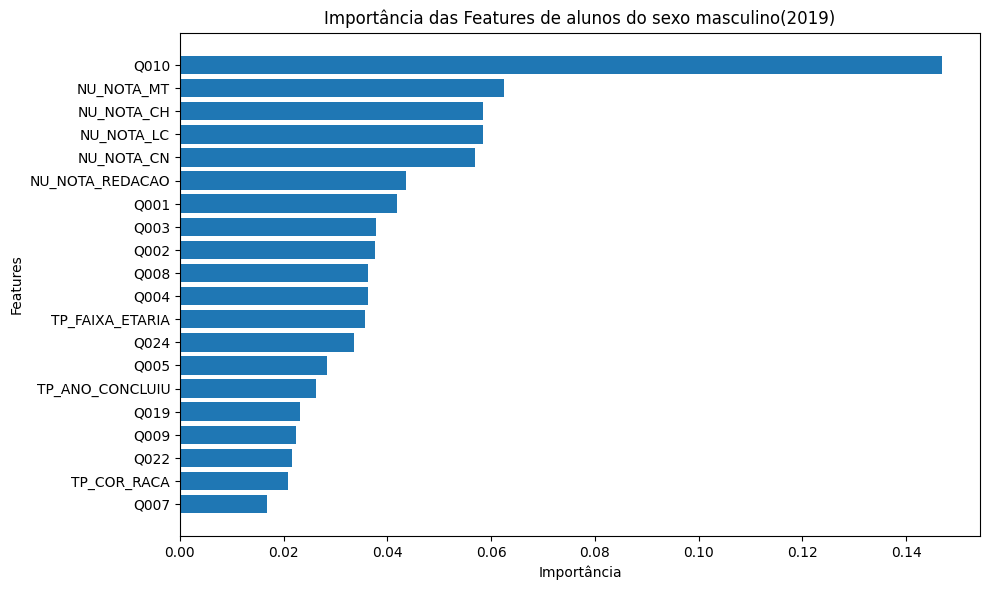

In [15]:
df_importancia_homem = analisar_importancia_features_agregada(modelo_homem, clf_homem, "de alunos do sexo masculino(2019)", 20)

Importância das features (sem agregação):
Q010_A: 0.1395
NU_NOTA_MT: 0.0625
NU_NOTA_CH: 0.0585
NU_NOTA_LC: 0.0584
NU_NOTA_CN: 0.0568
NU_NOTA_REDACAO: 0.0436
TP_FAIXA_ETARIA: 0.0356
Q005: 0.0284
Q008_B: 0.0284
TP_ANO_CONCLUIU: 0.0262
Q024_A: 0.0214
TP_COR_RACA: 0.0208
Q004_D: 0.0146
Q007_A: 0.0132
Q003_E: 0.0101
TP_ESTADO_CIVIL: 0.0094
Q014_A: 0.0092
Q021_A: 0.0088
Q003_D: 0.0088
Q018_A: 0.0085


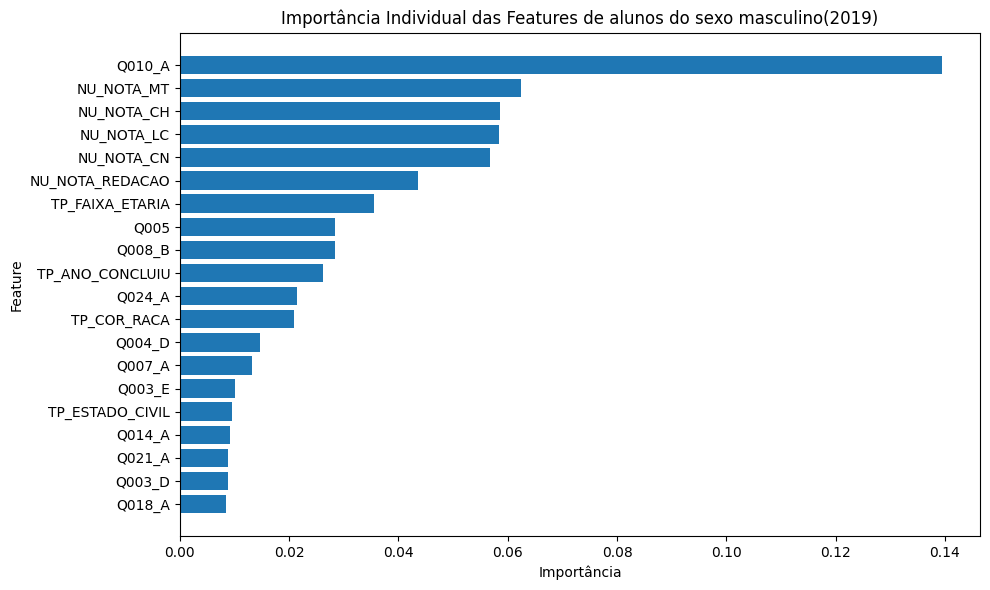

In [16]:
df_importancias_individuais_homem = analisar_importancia_features(modelo_homem, clf_homem, "de alunos do sexo masculino(2019)", top_n=20)

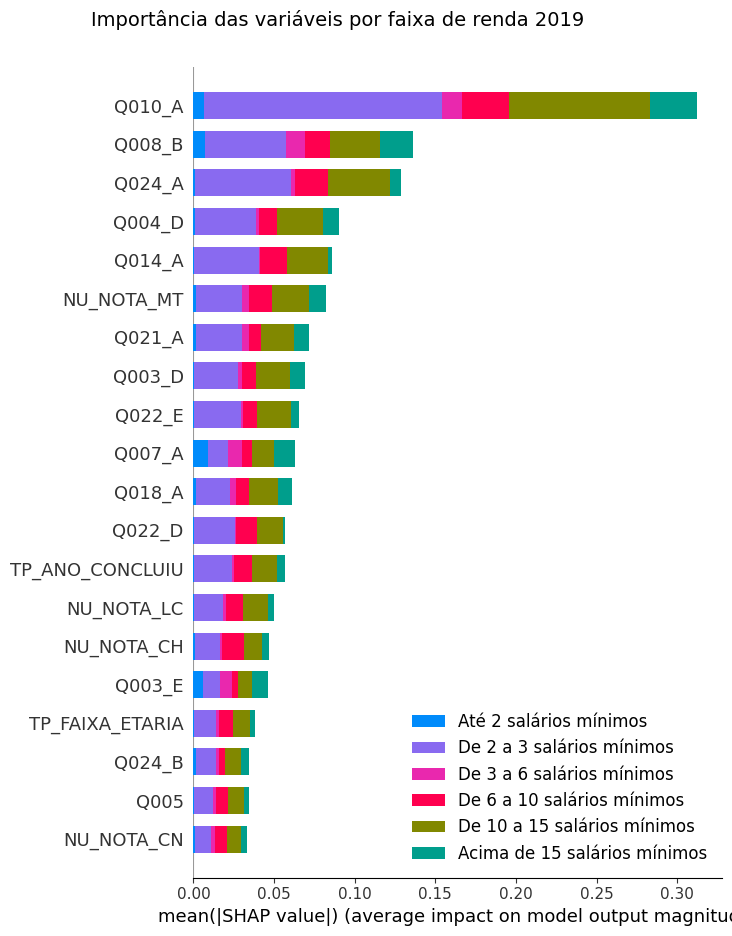

In [17]:
shap_multiclasses(df_transformado_homem, clf_homem, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


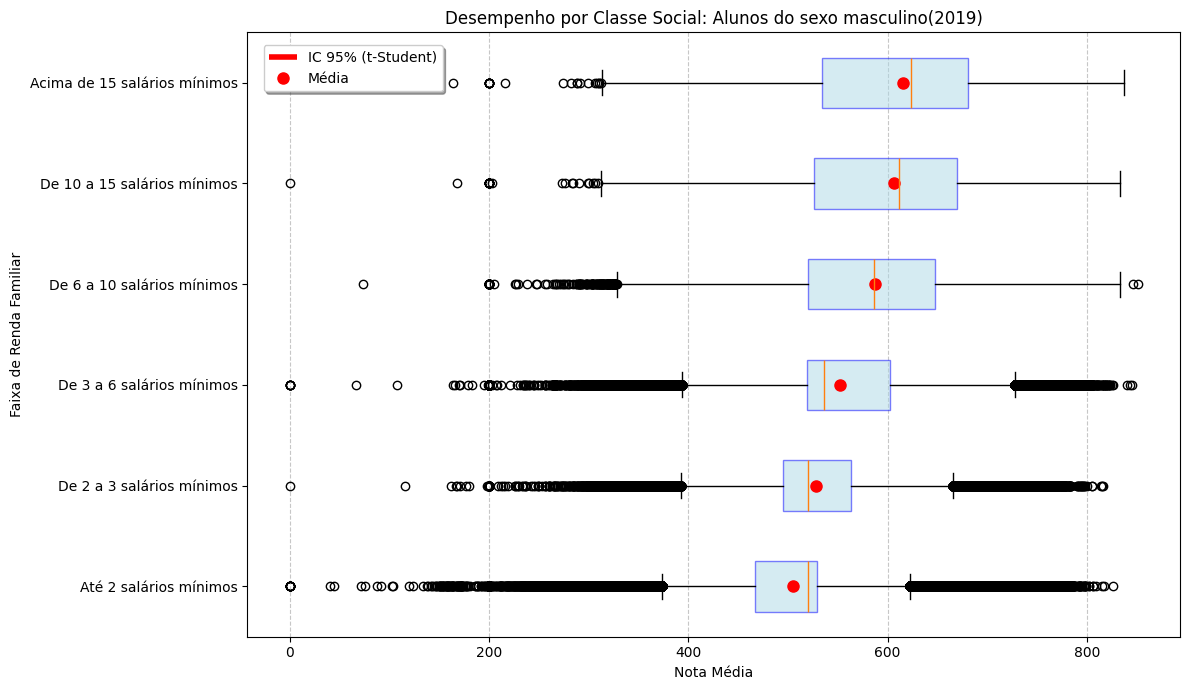

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,505.019603,519.979717,65.988072,1239805,4354.425710,467.120000,529.200000,0.00,826.30,826.30,13.066438,504.903448,505.135758
3,De 2 a 3 salários mínimos,527.647664,519.979717,67.564467,207039,4564.957263,494.880000,563.104767,0.00,816.02,816.02,12.804845,527.356630,527.938697
4,De 3 a 6 salários mínimos,552.530525,535.860000,75.601257,440525,5715.550049,518.940000,602.380000,0.00,845.00,845.00,13.682729,552.307274,552.753776
5,De 6 a 10 salários mínimos,587.435993,586.120000,81.349139,99575,6617.682403,519.979717,647.620000,73.74,850.82,777.08,13.848171,586.930714,587.941272
2,De 10 a 15 salários mínimos,606.707684,610.990000,82.666712,46414,6833.785305,525.925000,669.755000,0.00,832.82,832.82,13.625460,605.955602,607.459767
0,Acima de 15 salários mínimos,615.844835,623.240000,84.522825,30053,7144.108002,533.729533,681.040000,0.00,837.48,837.48,13.724695,614.889192,616.800478


In [9]:
analisar_desempenho_por_classe(dataset_homem, "Alunos do sexo masculino(2019)")

In [19]:
modelo_mulher, clf_mulher, df_transformado_mulher = treinar_modelo(dataset_mulher)

Acurácia: 0.9999079742459825

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     27096
      Até 2 salários mínimos       1.00      1.00      1.00   2076545
 De 10 a 15 salários mínimos       1.00      1.00      1.00     47041
   De 2 a 3 salários mínimos       1.00      1.00      1.00    268515
   De 3 a 6 salários mínimos       1.00      1.00      1.00    504980
  De 6 a 10 salários mínimos       1.00      1.00      1.00    107583

                    accuracy                           1.00   3031760
                   macro avg       1.00      1.00      1.00   3031760
                weighted avg       1.00      1.00      1.00   3031760


Matriz de confusão:
 [[  27096       0       0       0       0       0]
 [      0 2076543       0       1       1       0]
 [      0       0   47041       0       0       0]
 [      0     180       0  268335       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1556
Feature NU_NOTA_LC: 0.0664
Feature NU_NOTA_MT: 0.0610
Feature NU_NOTA_CH: 0.0599
Feature NU_NOTA_CN: 0.0582
Feature NU_NOTA_REDACAO: 0.0431
Feature Q008: 0.0420
Feature Q004: 0.0404
Feature Q001: 0.0398
Feature Q002: 0.0365
Feature Q003: 0.0359
Feature TP_FAIXA_ETARIA: 0.0338
Feature Q024: 0.0313
Feature Q005: 0.0276
Feature TP_ANO_CONCLUIU: 0.0237
Feature Q019: 0.0219
Feature Q009: 0.0216
Feature Q022: 0.0204
Feature TP_COR_RACA: 0.0191
Feature Q013: 0.0158


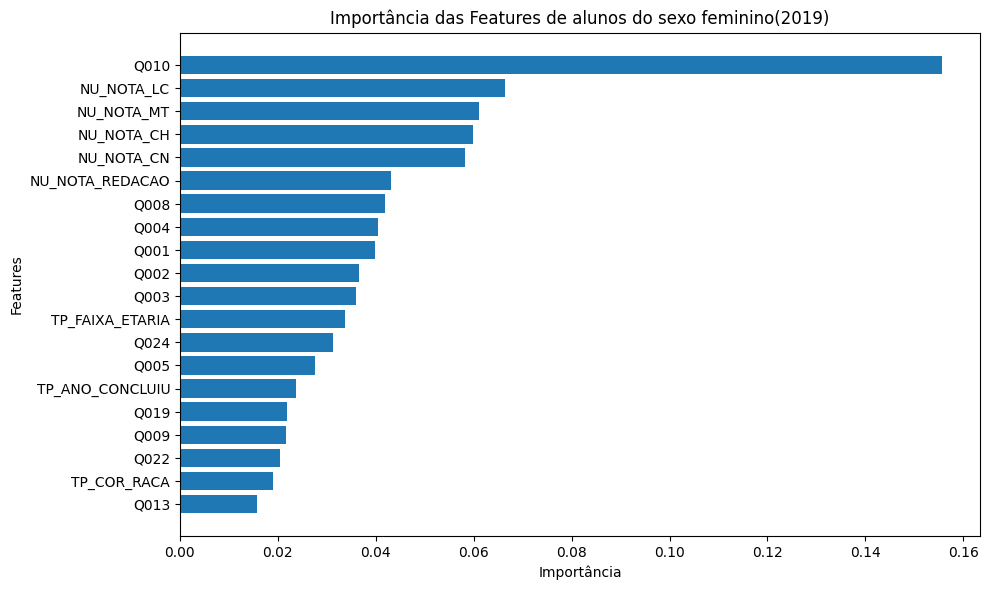

In [20]:
df_importancias_mulher = analisar_importancia_features_agregada(modelo_mulher,clf_mulher, "de alunos do sexo feminino(2019)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1485
NU_NOTA_LC: 0.0664
NU_NOTA_MT: 0.0610
NU_NOTA_CH: 0.0599
NU_NOTA_CN: 0.0582
NU_NOTA_REDACAO: 0.0431
Q008_B: 0.0347
TP_FAIXA_ETARIA: 0.0338
Q005: 0.0276
TP_ANO_CONCLUIU: 0.0237
Q024_A: 0.0210
Q004_D: 0.0199
TP_COR_RACA: 0.0191
Q007_A: 0.0114
Q014_A: 0.0098
Q003_D: 0.0089
TP_ESCOLA: 0.0086
Q022_E: 0.0082
TP_ESTADO_CIVIL: 0.0082
Q003_E: 0.0082


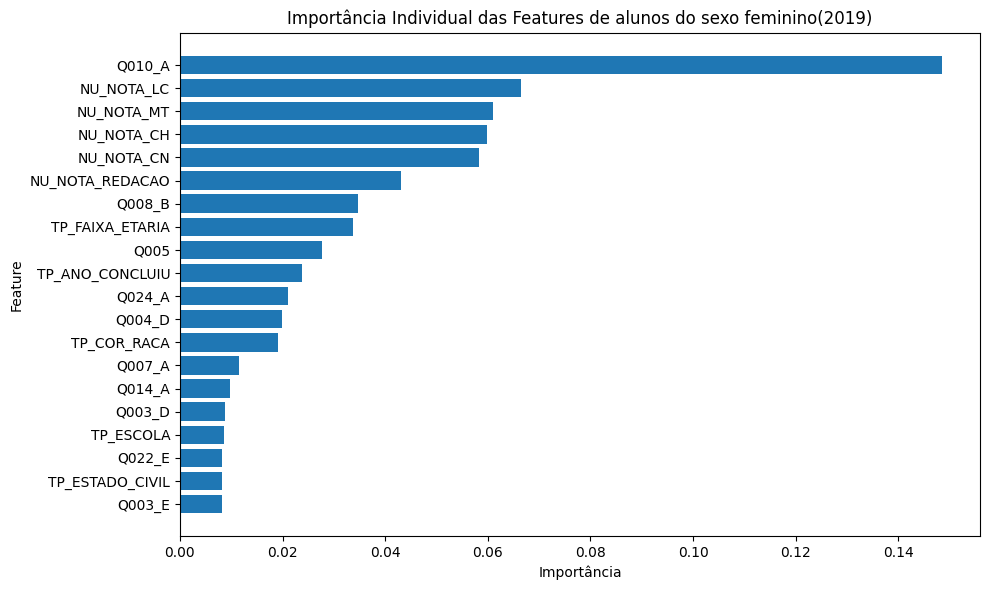

In [21]:
df_importancias_individuais_mulher = analisar_importancia_features(modelo_mulher, clf_mulher, "de alunos do sexo feminino(2019)", top_n=20)

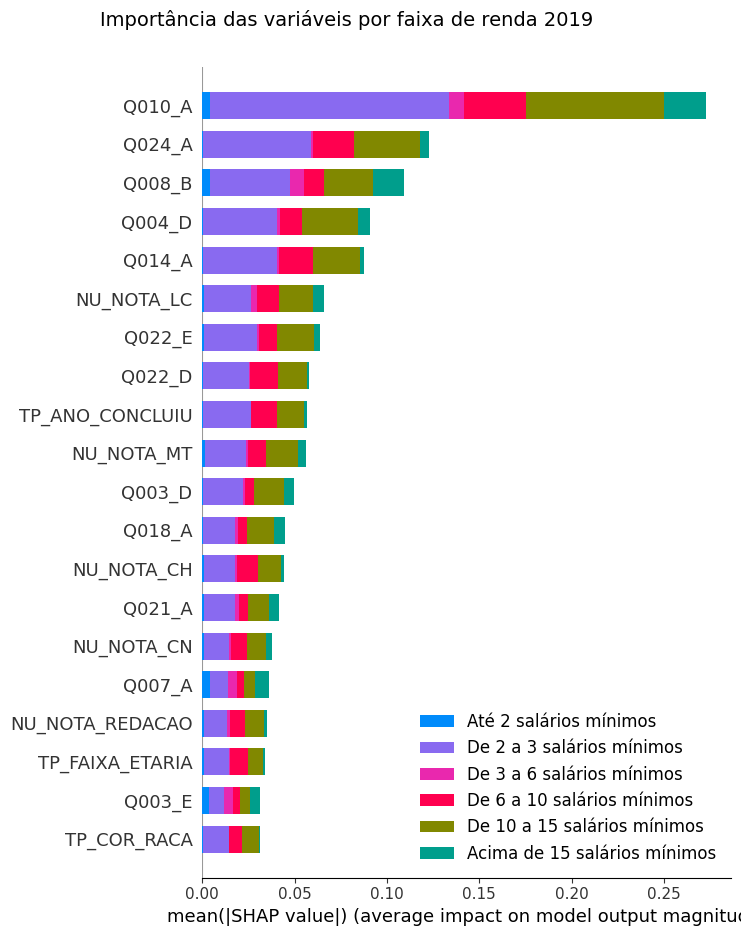

In [22]:
shap_multiclasses(df_transformado_mulher, clf_mulher, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


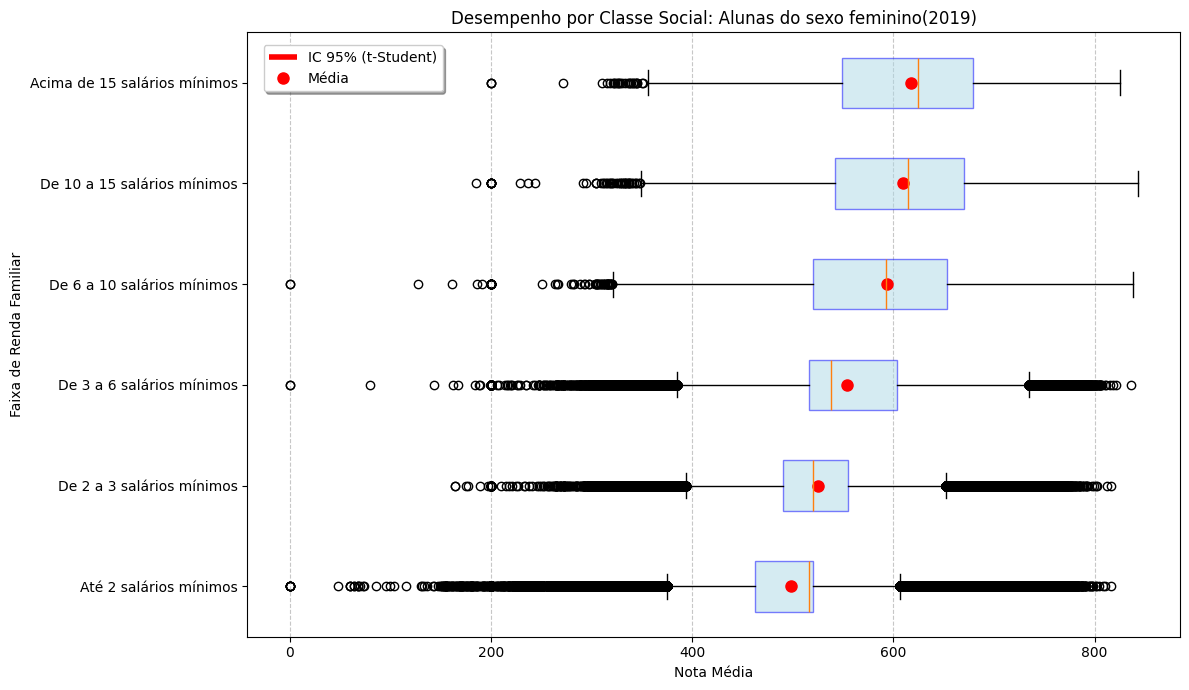

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,498.614822,515.640000,60.524119,2076545,3663.168943,462.000000,519.979717,0.000000,816.10,816.100000,12.138452,498.532502,498.697142
3,De 2 a 3 salários mínimos,524.792936,519.979717,64.804183,268515,4199.582129,490.620000,555.260000,164.080000,816.18,652.100000,12.348524,524.547822,525.038050
4,De 3 a 6 salários mínimos,554.283837,538.120000,74.507885,504980,5551.424934,516.180000,603.640000,0.000000,835.90,835.900000,13.442190,554.078336,554.489338
5,De 6 a 10 salários mínimos,593.218792,592.760000,78.507836,107583,6163.480316,519.979717,652.860000,0.000000,838.56,838.560000,13.234213,592.749661,593.687923
2,De 10 a 15 salários mínimos,609.880462,614.060000,78.821365,47041,6212.807549,541.560000,670.380000,184.900000,842.70,657.800000,12.924068,609.168159,610.592766
0,Acima de 15 salários mínimos,617.365942,624.740000,79.414068,27096,6306.594269,548.627150,678.860000,200.189533,825.30,625.110467,12.863370,616.420332,618.311553


In [10]:
analisar_desempenho_por_classe(dataset_mulher, "Alunas do sexo feminino(2019)")

In [11]:
# Filtrar apenas escolas urbanas
dataset_urbano = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 1]
num_columns = dataset_urbano.shape[1]
num_rows = dataset_urbano.shape[0]
print(f"Número de colunas dataset urbano: {num_columns}")
print(f"Número de linhas dataset urbano: {num_rows}")

# Filtrar apenas escolas rurais
dataset_rural = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 2]
num_columns = dataset_rural.shape[1]
num_rows = dataset_rural.shape[0]
print(f"Número de colunas dataset rural: {num_columns}")
print(f"Número de linhas dataset rural: {num_rows}")

Número de colunas dataset urbano: 40
Número de linhas dataset urbano: 5053630
Número de colunas dataset rural: 40
Número de linhas dataset rural: 41541


In [25]:
modelo_urbano, clf_urbano, df_transformado_urbano = treinar_modelo(dataset_urbano)

Acurácia: 0.9999194638309492

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     57090
      Até 2 salários mínimos       1.00      1.00      1.00   3282537
 De 10 a 15 salários mínimos       1.00      1.00      1.00     93335
   De 2 a 3 salários mínimos       1.00      1.00      1.00    472766
   De 3 a 6 salários mínimos       1.00      1.00      1.00    941301
  De 6 a 10 salários mínimos       1.00      1.00      1.00    206601

                    accuracy                           1.00   5053630
                   macro avg       1.00      1.00      1.00   5053630
                weighted avg       1.00      1.00      1.00   5053630


Matriz de confusão:
 [[  57090       0       0       0       0       0]
 [      0 3282535       0       1       1       0]
 [      0       0   93335       0       0       0]
 [      0     248       0  472518       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1528
Feature NU_NOTA_MT: 0.0630
Feature NU_NOTA_CH: 0.0594
Feature NU_NOTA_LC: 0.0591
Feature NU_NOTA_CN: 0.0574
Feature NU_NOTA_REDACAO: 0.0429
Feature Q001: 0.0392
Feature Q008: 0.0391
Feature Q004: 0.0366
Feature Q003: 0.0360
Feature Q002: 0.0355
Feature TP_FAIXA_ETARIA: 0.0338
Feature Q024: 0.0333
Feature Q005: 0.0279
Feature TP_ANO_CONCLUIU: 0.0241
Feature Q019: 0.0220
Feature Q009: 0.0216
Feature TP_COR_RACA: 0.0199
Feature Q022: 0.0199
Feature Q013: 0.0155


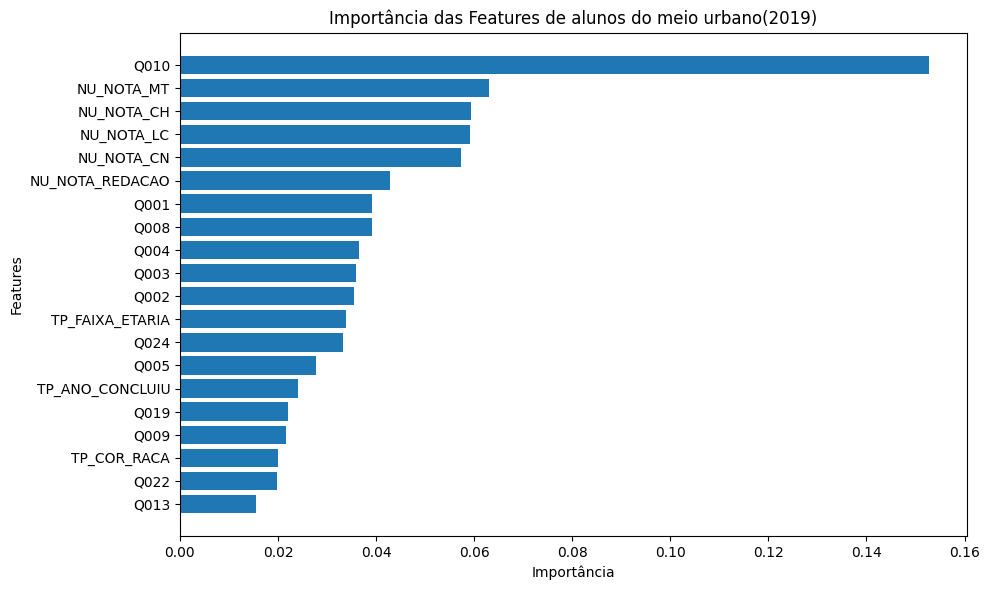

In [26]:
df_importancia_urbano = analisar_importancia_features_agregada(modelo_urbano, clf_urbano, "de alunos do meio urbano(2019)", 20)

Importância das features (sem agregação):
Q010_A: 0.1463
NU_NOTA_MT: 0.0630
NU_NOTA_CH: 0.0594
NU_NOTA_LC: 0.0591
NU_NOTA_CN: 0.0574
NU_NOTA_REDACAO: 0.0429
TP_FAIXA_ETARIA: 0.0338
Q008_B: 0.0317
Q005: 0.0279
TP_ANO_CONCLUIU: 0.0241
Q024_A: 0.0229
TP_COR_RACA: 0.0199
Q004_D: 0.0162
Q007_A: 0.0121
Q003_E: 0.0093
Q003_D: 0.0090
Q014_A: 0.0089
TP_ESTADO_CIVIL: 0.0087
TP_ESCOLA: 0.0083
Q022_E: 0.0078


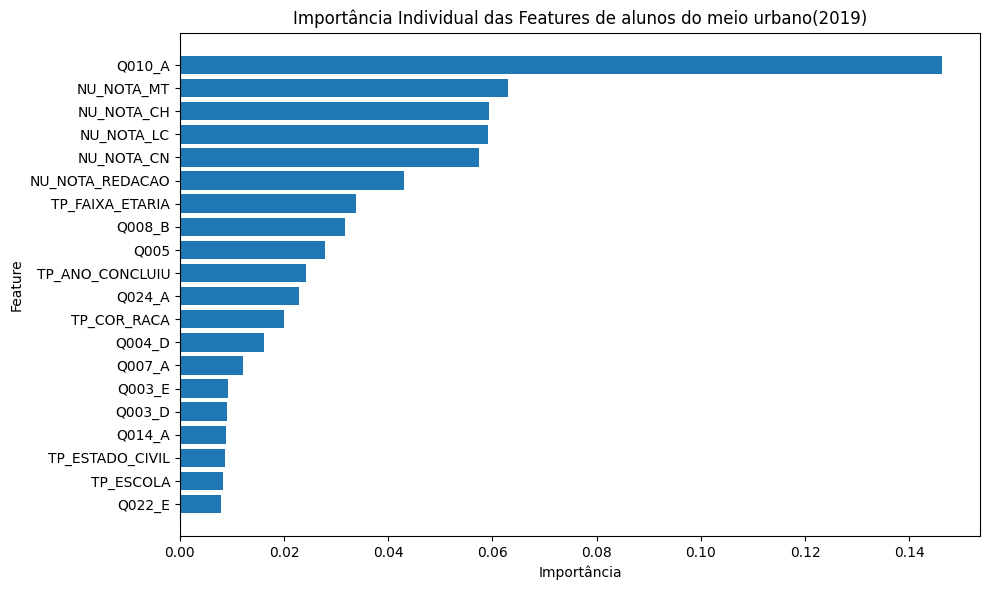

In [27]:
df_importancias_individuais_urbano = analisar_importancia_features(modelo_urbano, clf_urbano, "de alunos do meio urbano(2019)", top_n=20)

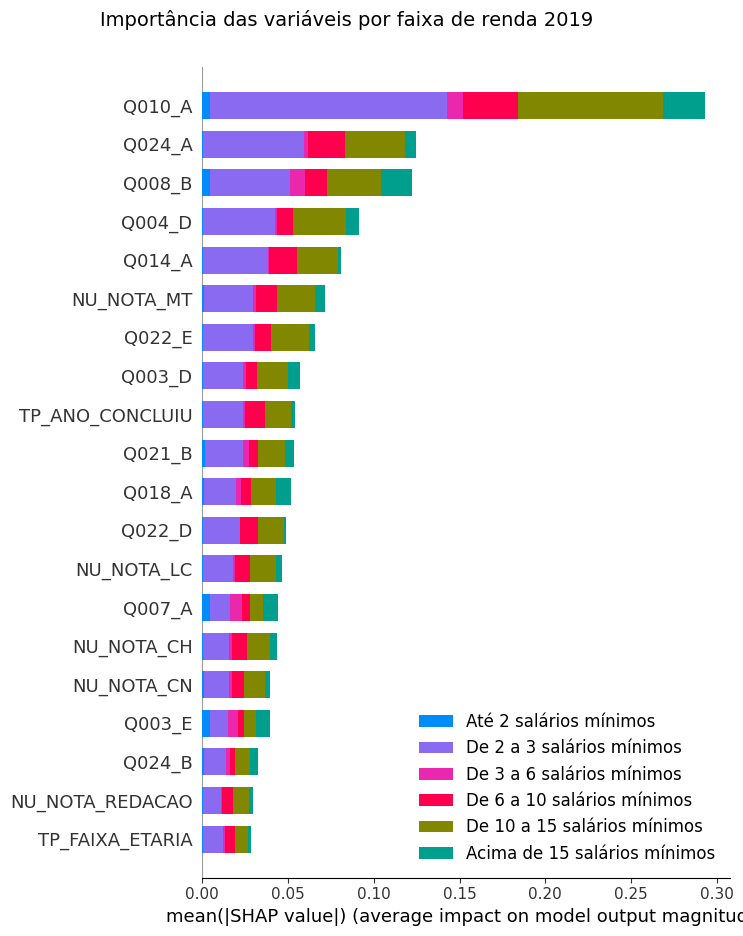

In [28]:
shap_multiclasses(df_transformado_urbano, clf_urbano, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


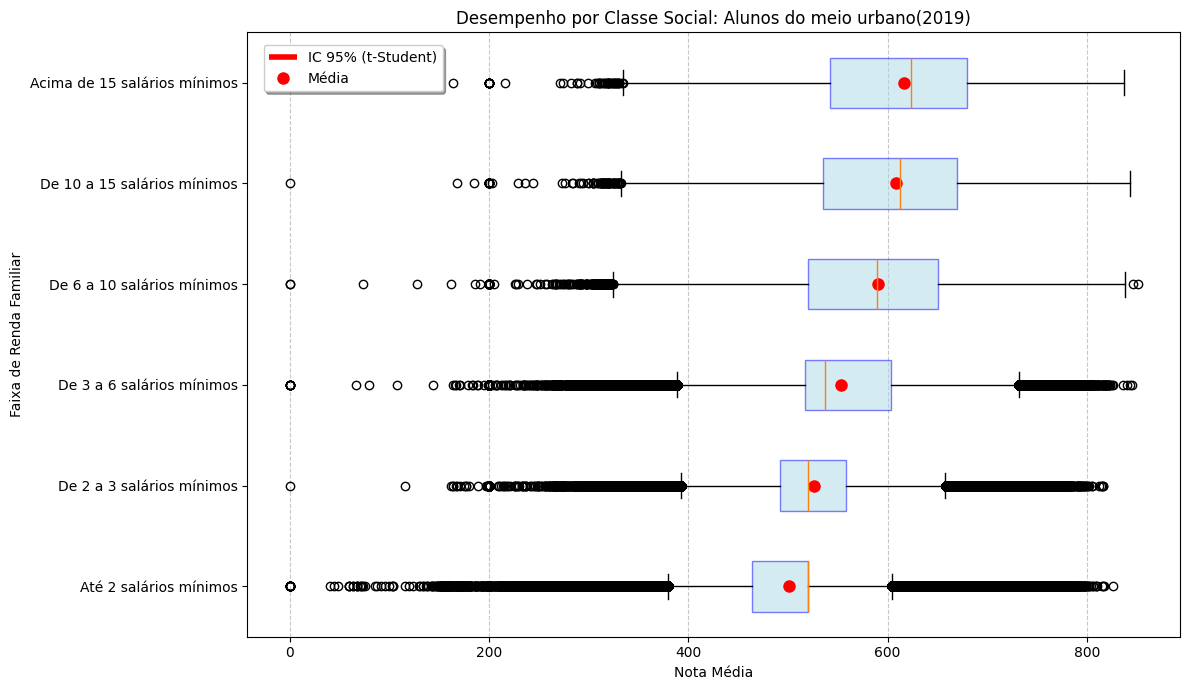

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,501.164145,519.979717,62.613878,3282537,3920.497761,463.940000,519.979717,0.0,826.30,826.30,12.493687,501.096410,501.231880
3,De 2 a 3 salários mínimos,526.046369,519.979717,66.000336,472766,4356.044359,492.420000,558.680000,0.0,816.18,816.18,12.546486,525.858233,526.234505
4,De 3 a 6 salários mínimos,553.487039,537.080000,75.022691,941301,5628.404193,517.400000,603.020000,0.0,845.00,845.00,13.554552,553.335481,553.638596
5,De 6 a 10 salários mínimos,590.482587,589.720000,79.932246,206601,6389.163967,519.979717,650.480000,0.0,850.82,850.82,13.536766,590.137915,590.827260
2,De 10 a 15 salários mínimos,608.340961,612.680000,80.772348,93335,6524.172278,534.940000,670.070000,0.0,842.70,842.70,13.277480,607.822765,608.859157
0,Acima de 15 salários mínimos,616.616620,623.920000,82.124220,57090,6744.387590,541.825000,680.000000,0.0,837.48,837.48,13.318522,615.942948,617.290292


In [12]:
analisar_desempenho_por_classe(dataset_urbano, "Alunos do meio urbano(2019)")

In [13]:
# Filtrar apenas homens do meio urbano
dataset_urbano_homem = dataset_urbano[dataset_urbano['TP_SEXO'] == "M"]
num_columns = dataset_urbano_homem.shape[1]
num_rows = dataset_urbano_homem.shape[0]
print(f"Número de colunas dataset urbano homem: {num_columns}")
print(f"Número de linhas dataset urbano homem: {num_rows}")

# Filtrar apenas mulheres do meio urbano
dataset_urbano_mulher = dataset_urbano[dataset_urbano['TP_SEXO'] == "F"]
num_columns = dataset_urbano_mulher.shape[1]
num_rows = dataset_urbano_mulher.shape[0]
print(f"Número de colunas dataset urbano mulher: {num_columns}")
print(f"Número de linhas dataset urbano mulher: {num_rows}")

Número de colunas dataset urbano homem: 40
Número de linhas dataset urbano homem: 2045479
Número de colunas dataset urbano mulher: 40
Número de linhas dataset urbano mulher: 3008151


In [31]:
modelo_urbano_homem, clf_urbano_homem, df_transformado_urbano_homem = treinar_modelo(dataset_urbano_homem)

Acurácia: 0.9999374229703654

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     30018
      Até 2 salários mínimos       1.00      1.00      1.00   1225827
 De 10 a 15 salários mínimos       1.00      1.00      1.00     46354
   De 2 a 3 salários mínimos       1.00      1.00      1.00    205683
   De 3 a 6 salários mínimos       1.00      1.00      1.00    438319
  De 6 a 10 salários mínimos       1.00      1.00      1.00     99278

                    accuracy                           1.00   2045479
                   macro avg       1.00      1.00      1.00   2045479
                weighted avg       1.00      1.00      1.00   2045479


Matriz de confusão:
 [[  30018       0       0       0       0       0]
 [      0 1225827       0       0       0       0]
 [      0       0   46354       0       0       0]
 [      0      68       0  205615       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1468
Feature NU_NOTA_MT: 0.0628
Feature NU_NOTA_CH: 0.0585
Feature NU_NOTA_LC: 0.0582
Feature NU_NOTA_CN: 0.0567
Feature NU_NOTA_REDACAO: 0.0435
Feature Q001: 0.0419
Feature Q003: 0.0377
Feature Q002: 0.0371
Feature Q008: 0.0362
Feature Q004: 0.0360
Feature TP_FAIXA_ETARIA: 0.0359
Feature Q024: 0.0335
Feature Q005: 0.0288
Feature TP_ANO_CONCLUIU: 0.0265
Feature Q019: 0.0237
Feature Q009: 0.0222
Feature Q022: 0.0216
Feature TP_COR_RACA: 0.0211
Feature Q007: 0.0169


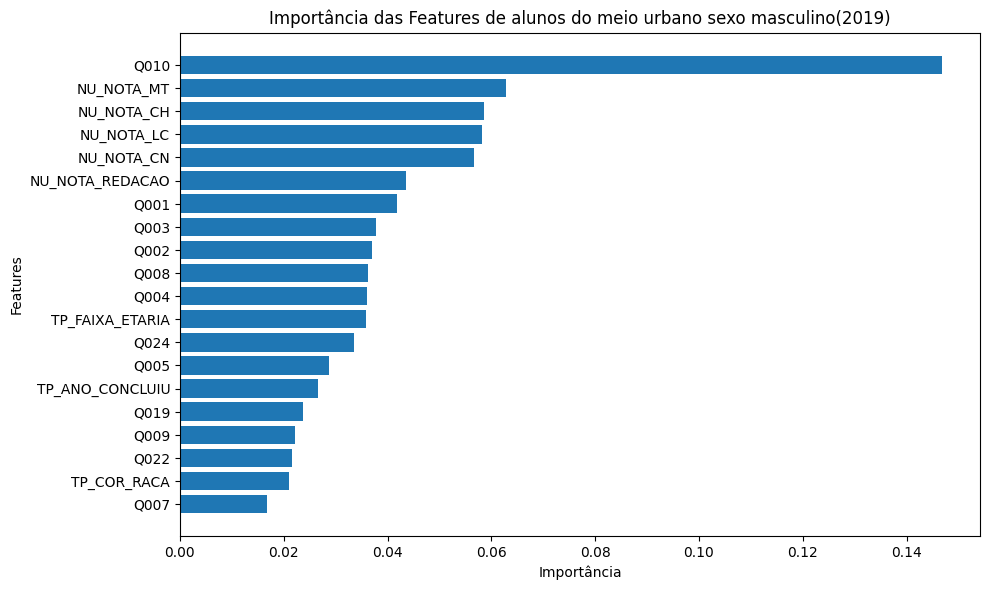

In [32]:
df_importancia_urbano_homem = analisar_importancia_features_agregada(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2019)", 20)

Importância das features (sem agregação):
Q010_A: 0.1393
NU_NOTA_MT: 0.0628
NU_NOTA_CH: 0.0585
NU_NOTA_LC: 0.0582
NU_NOTA_CN: 0.0567
NU_NOTA_REDACAO: 0.0435
TP_FAIXA_ETARIA: 0.0359
Q005: 0.0288
Q008_B: 0.0283
TP_ANO_CONCLUIU: 0.0265
Q024_A: 0.0213
TP_COR_RACA: 0.0211
Q004_D: 0.0145
Q007_A: 0.0133
Q003_E: 0.0100
TP_ESTADO_CIVIL: 0.0094
Q014_A: 0.0092
Q003_D: 0.0087
TP_ESCOLA: 0.0086
Q001_E: 0.0084


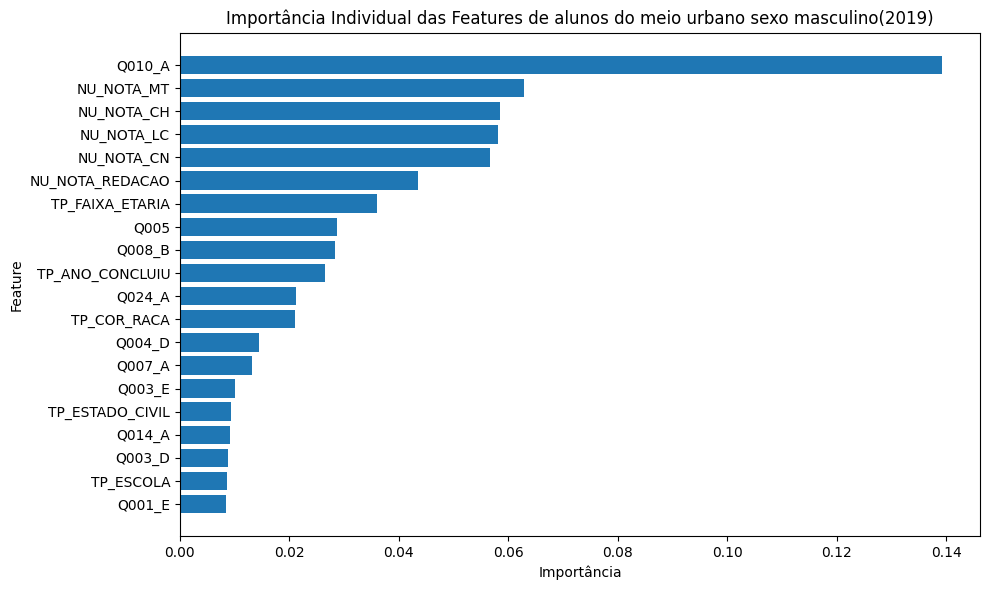

In [33]:
df_importancias_individuais_urbano_homem = analisar_importancia_features(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2019)", top_n=20)

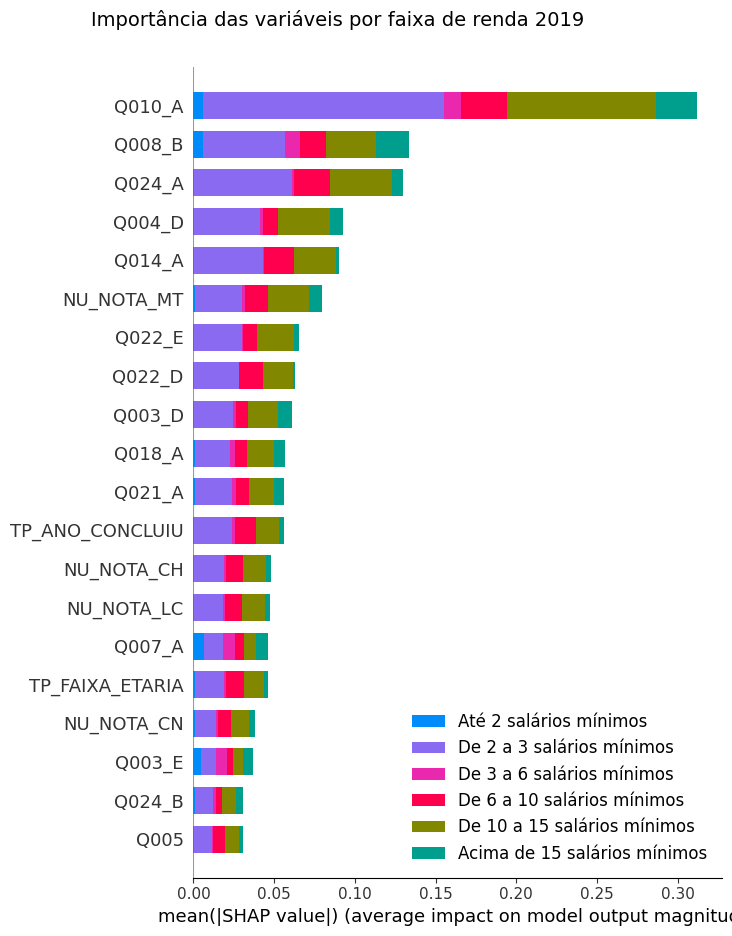

In [34]:
shap_multiclasses(df_transformado_urbano_homem, clf_urbano_homem, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


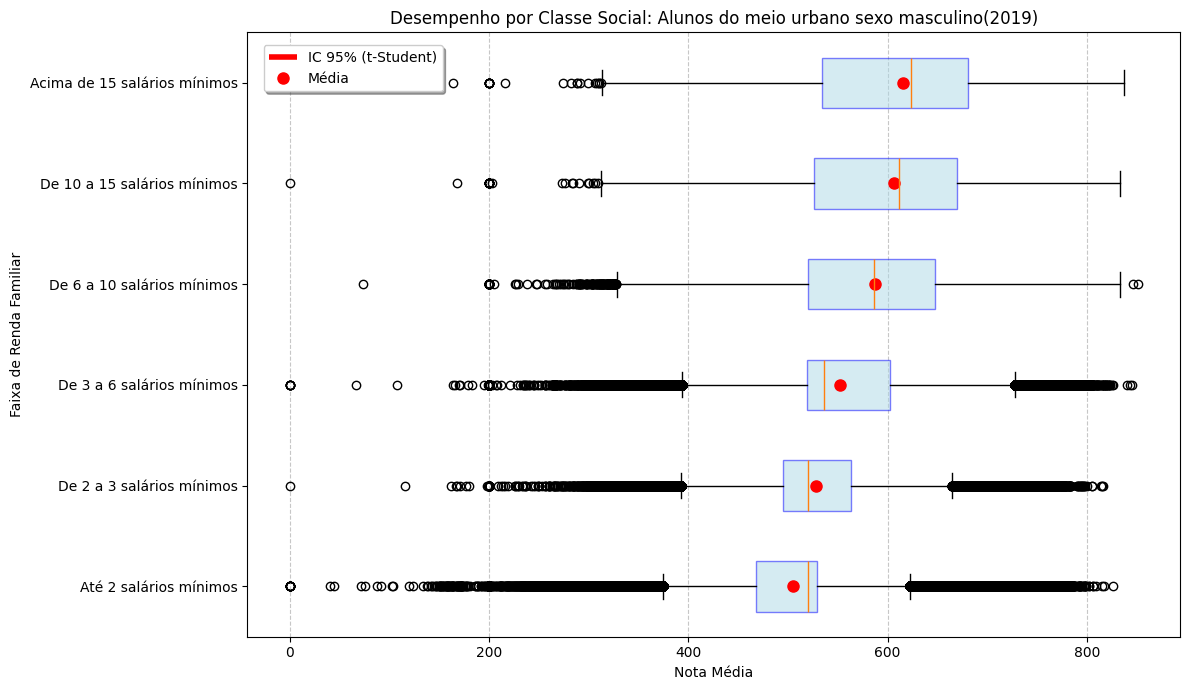

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,505.227483,519.979717,65.870642,1225827,4338.941420,467.460000,529.340000,0.00,826.30,826.30,13.037818,505.110875,505.344090
3,De 2 a 3 salários mínimos,527.680729,519.979717,67.501146,205683,4556.404744,495.040000,563.014767,0.00,816.02,816.02,12.792043,527.389011,527.972446
4,De 3 a 6 salários mínimos,552.558060,535.820000,75.588534,438319,5713.626454,519.040000,602.380000,0.00,845.00,845.00,13.679745,552.334286,552.781835
5,De 6 a 10 salários mínimos,587.480807,586.180000,81.357184,99278,6618.991449,519.979717,647.700000,73.74,850.82,777.08,13.848484,586.974722,587.986891
2,De 10 a 15 salários mínimos,606.732737,611.040000,82.667589,46354,6833.930231,525.925000,669.760000,0.00,832.82,832.82,13.625042,605.980159,607.485314
0,Acima de 15 salários mínimos,615.916920,623.330000,84.495085,30018,7139.419470,533.835000,681.075000,0.00,837.48,837.48,13.718585,614.961034,616.872806


In [14]:
analisar_desempenho_por_classe(dataset_urbano_homem, "Alunos do meio urbano sexo masculino(2019)")

In [36]:
modelo_urbano_mulher, clf_urbano_mulher, df_transformado_urbano_mulher = treinar_modelo(dataset_urbano_mulher)

Acurácia: 0.999907251996326

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     27072
      Até 2 salários mínimos       1.00      1.00      1.00   2056710
 De 10 a 15 salários mínimos       1.00      1.00      1.00     46981
   De 2 a 3 salários mínimos       1.00      1.00      1.00    267083
   De 3 a 6 salários mínimos       1.00      1.00      1.00    502982
  De 6 a 10 salários mínimos       1.00      1.00      1.00    107323

                    accuracy                           1.00   3008151
                   macro avg       1.00      1.00      1.00   3008151
                weighted avg       1.00      1.00      1.00   3008151


Matriz de confusão:
 [[  27072       0       0       0       0       0]
 [      0 2056708       0       1       1       0]
 [      0       0   46981       0       0       0]
 [      0     180       0  266903       0       0]
 [      0    

Importância das features (agregada):
Feature Q010: 0.1556
Feature NU_NOTA_LC: 0.0664
Feature NU_NOTA_MT: 0.0612
Feature NU_NOTA_CH: 0.0597
Feature NU_NOTA_CN: 0.0586
Feature NU_NOTA_REDACAO: 0.0430
Feature Q008: 0.0417
Feature Q004: 0.0403
Feature Q001: 0.0399
Feature Q002: 0.0366
Feature Q003: 0.0362
Feature TP_FAIXA_ETARIA: 0.0335
Feature Q024: 0.0311
Feature Q005: 0.0278
Feature TP_ANO_CONCLUIU: 0.0238
Feature Q009: 0.0219
Feature Q019: 0.0218
Feature Q022: 0.0205
Feature TP_COR_RACA: 0.0192
Feature Q013: 0.0156


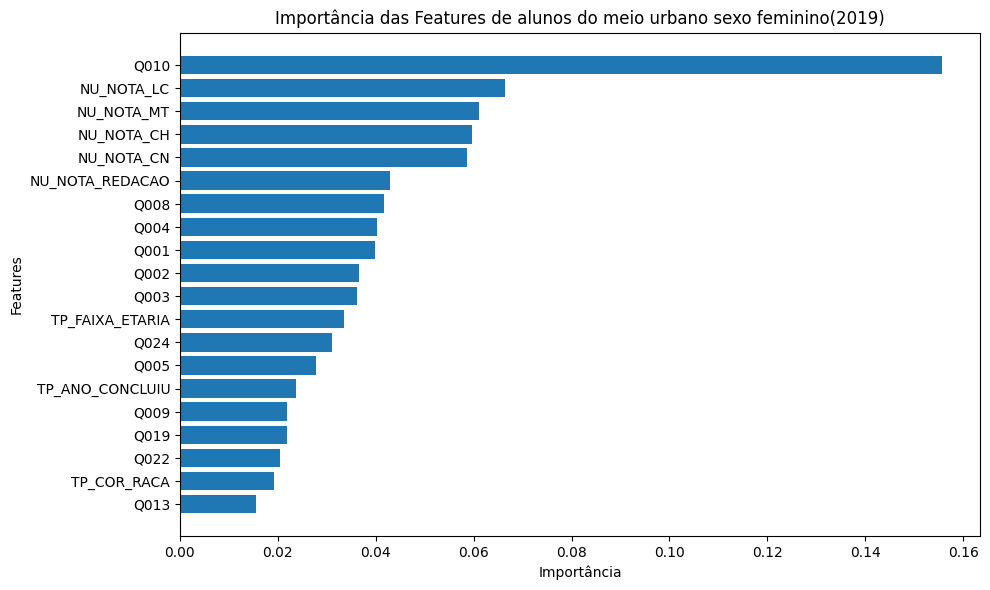

In [37]:
df_importancia_urbano_mulher = analisar_importancia_features_agregada(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2019)", 20)

Importância das features (sem agregação):
Q010_A: 0.1485
NU_NOTA_LC: 0.0664
NU_NOTA_MT: 0.0612
NU_NOTA_CH: 0.0597
NU_NOTA_CN: 0.0586
NU_NOTA_REDACAO: 0.0430
Q008_B: 0.0346
TP_FAIXA_ETARIA: 0.0335
Q005: 0.0278
TP_ANO_CONCLUIU: 0.0238
Q024_A: 0.0209
Q004_D: 0.0198
TP_COR_RACA: 0.0192
Q007_A: 0.0114
Q014_A: 0.0098
Q003_D: 0.0089
TP_ESCOLA: 0.0083
TP_ESTADO_CIVIL: 0.0083
Q003_E: 0.0082
Q022_E: 0.0082


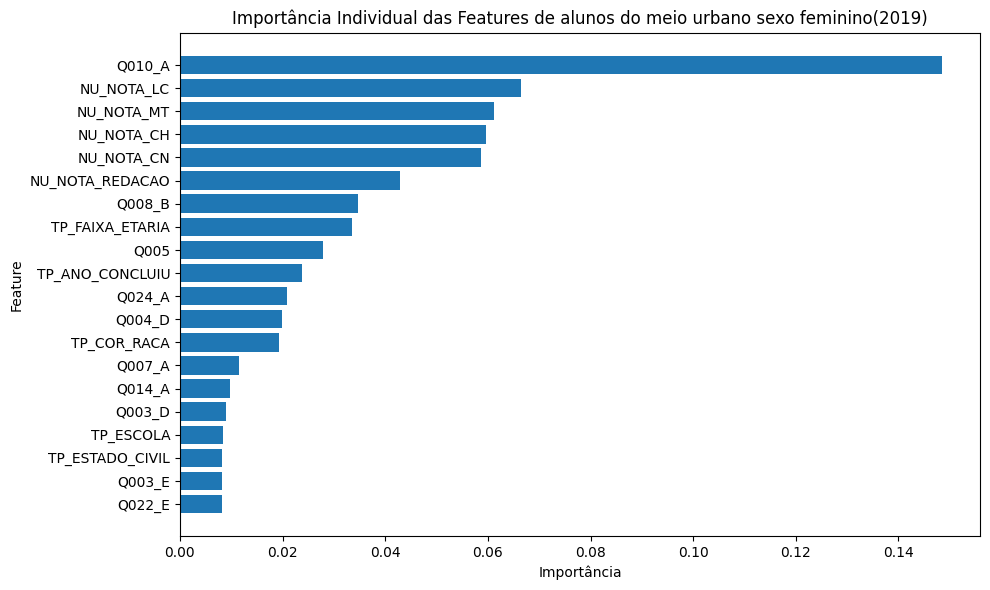

In [38]:
df_importancias_individuais_urbano_mulher = analisar_importancia_features(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2019)", top_n=20)

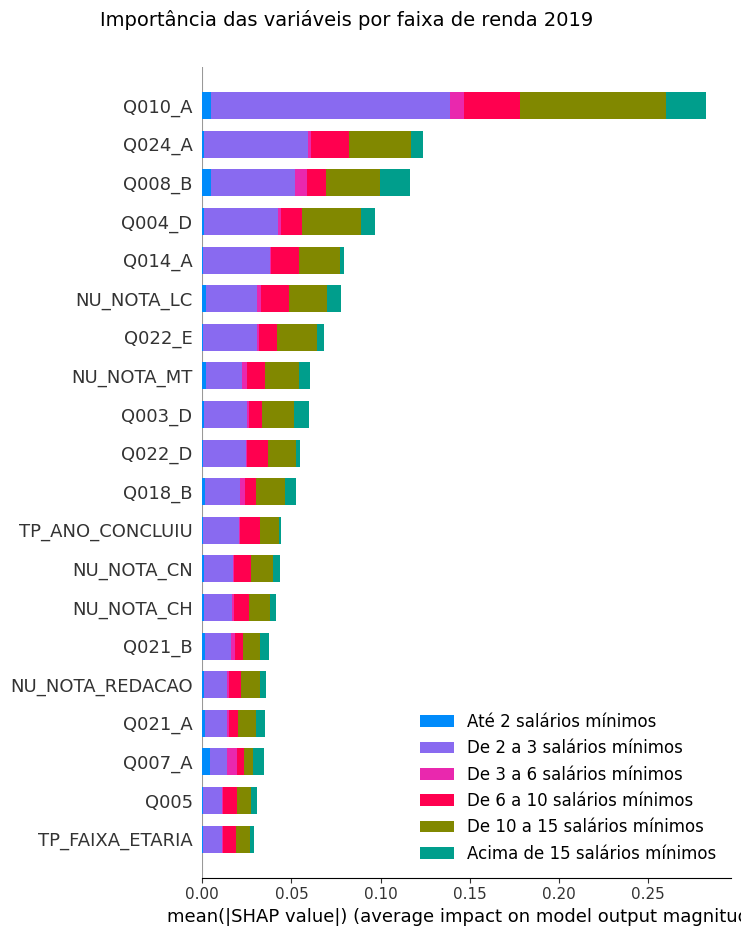

In [39]:
shap_multiclasses(df_transformado_urbano_mulher, clf_urbano_mulher, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


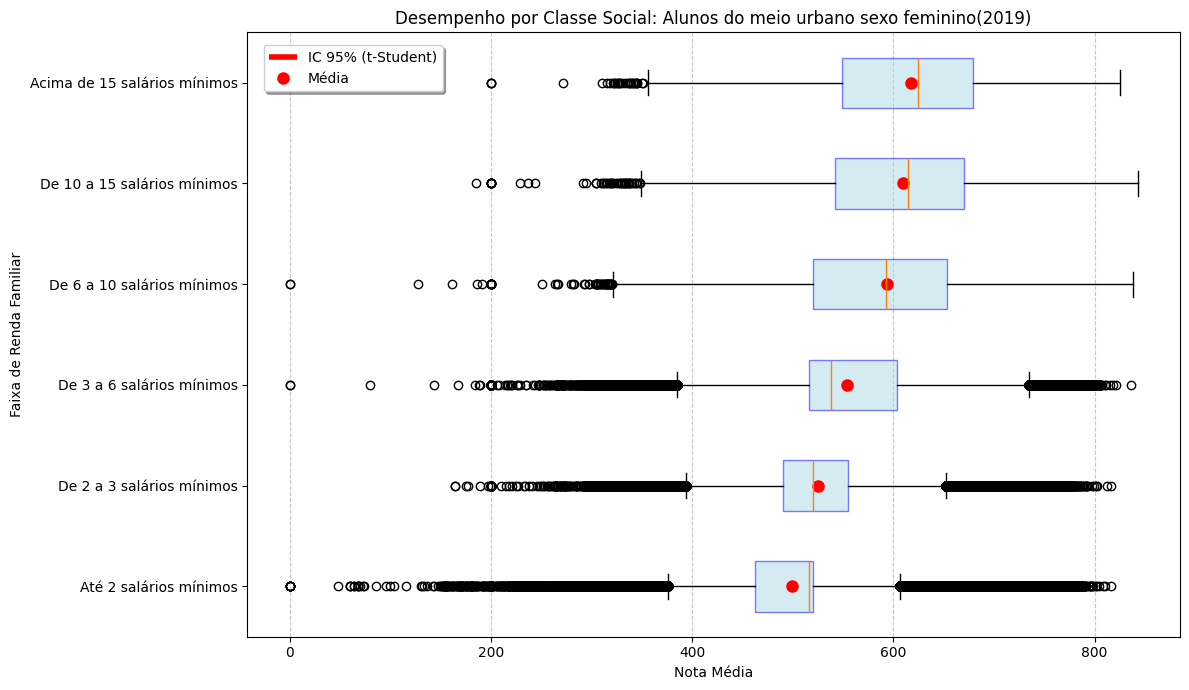

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,498.742340,515.880000,60.459870,2056710,3655.395911,462.209533,519.979717,0.000000,816.10,816.100000,12.122466,498.659712,498.824969
3,De 2 a 3 salários mínimos,524.787734,519.979717,64.792903,267083,4198.120283,490.660000,555.180000,164.080000,816.18,652.100000,12.346497,524.542006,525.033461
4,De 3 a 6 salários mínimos,554.296589,538.080000,74.516722,502982,5552.741827,516.220000,603.640000,0.000000,835.90,835.900000,13.443475,554.090655,554.502522
5,De 6 a 10 salários mínimos,593.259352,592.780000,78.489352,107323,6160.578380,519.979717,652.880000,0.000000,838.56,838.560000,13.230192,592.789764,593.728941
2,De 10 a 15 salários mínimos,609.927722,614.140000,78.826502,46981,6213.617473,541.600000,670.420000,184.900000,842.70,657.800000,12.923909,609.214917,610.640526
0,Acima de 15 salários mínimos,617.392462,624.740000,79.406994,27072,6305.470697,548.652383,678.905000,200.189533,825.30,625.110467,12.861672,616.446516,618.338407


In [15]:
analisar_desempenho_por_classe(dataset_urbano_mulher, "Alunos do meio urbano sexo feminino(2019)")

In [41]:
modelo_rural, clf_rural, df_transformado_rural = treinar_modelo(dataset_rural)

Acurácia: 0.9999759273970295

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        59
      Até 2 salários mínimos       1.00      1.00      1.00     33813
 De 10 a 15 salários mínimos       1.00      1.00      1.00       120
   De 2 a 3 salários mínimos       1.00      1.00      1.00      2788
   De 3 a 6 salários mínimos       1.00      1.00      1.00      4204
  De 6 a 10 salários mínimos       1.00      1.00      1.00       557

                    accuracy                           1.00     41541
                   macro avg       1.00      1.00      1.00     41541
                weighted avg       1.00      1.00      1.00     41541


Matriz de confusão:
 [[   59     0     0     0     0     0]
 [    0 33813     0     0     0     0]
 [    0     0   120     0     0     0]
 [    0     1     0  2787     0     0]
 [    0     0     0     0  4204     0]
 [    0     0     0  

Importância das features (agregada):
Feature Q010: 0.1535
Feature Q004: 0.0703
Feature NU_NOTA_MT: 0.0690
Feature NU_NOTA_LC: 0.0626
Feature NU_NOTA_CN: 0.0585
Feature NU_NOTA_CH: 0.0561
Feature Q001: 0.0439
Feature NU_NOTA_REDACAO: 0.0432
Feature Q003: 0.0415
Feature Q024: 0.0401
Feature Q002: 0.0367
Feature Q022: 0.0308
Feature Q008: 0.0261
Feature Q005: 0.0245
Feature Q019: 0.0213
Feature Q009: 0.0212
Feature TP_COR_RACA: 0.0198
Feature TP_FAIXA_ETARIA: 0.0191
Feature Q013: 0.0187
Feature Q011: 0.0177


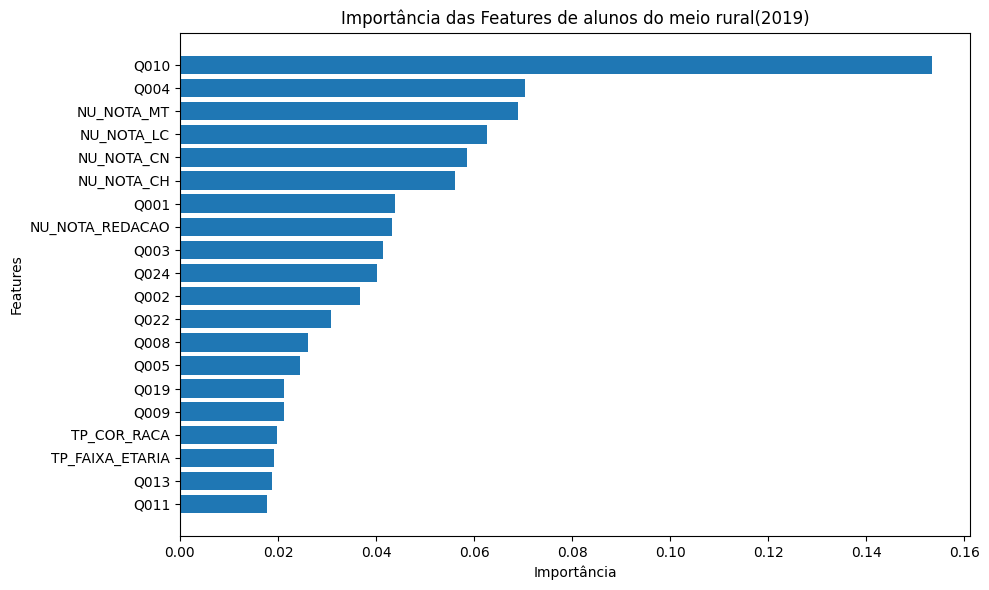

In [43]:
df_importancia_rural = analisar_importancia_features_agregada(modelo_rural,clf_rural, "de alunos do meio rural(2019)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1434
NU_NOTA_MT: 0.0690
NU_NOTA_LC: 0.0626
NU_NOTA_CN: 0.0585
NU_NOTA_CH: 0.0561
Q004_D: 0.0551
NU_NOTA_REDACAO: 0.0432
Q024_A: 0.0302
Q005: 0.0245
TP_COR_RACA: 0.0198
TP_FAIXA_ETARIA: 0.0191
Q008_B: 0.0185
Q003_D: 0.0132
Q014_A: 0.0126
Q022_E: 0.0102
Q003_A: 0.0093
Q013_A: 0.0081
Q001_D: 0.0079
Q021_A: 0.0078
Q001_E: 0.0077


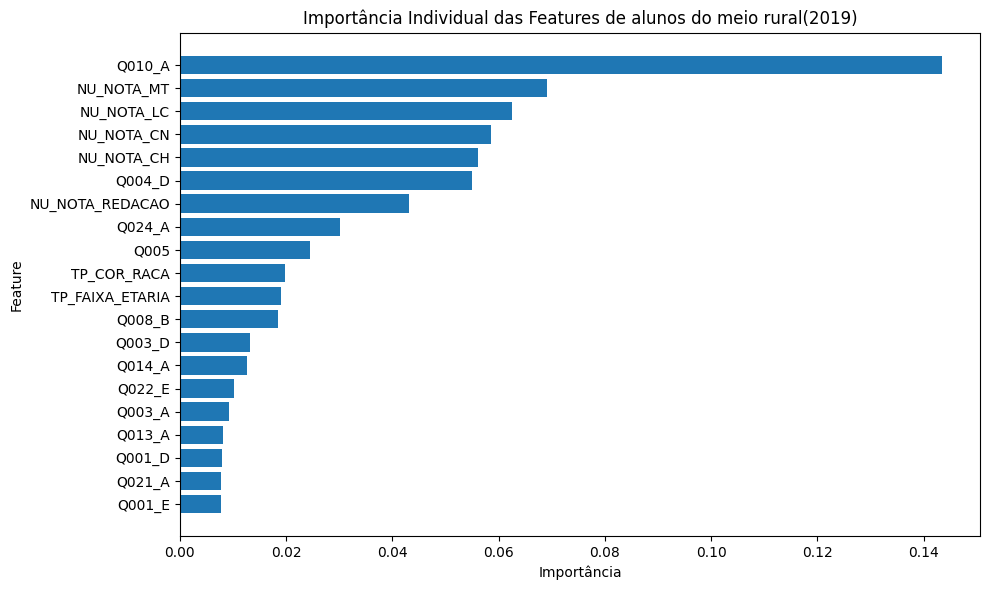

In [42]:
df_importancias_individuais_rural = analisar_importancia_features(modelo_rural, clf_rural, "de alunos do meio rural(2019)", top_n=20)

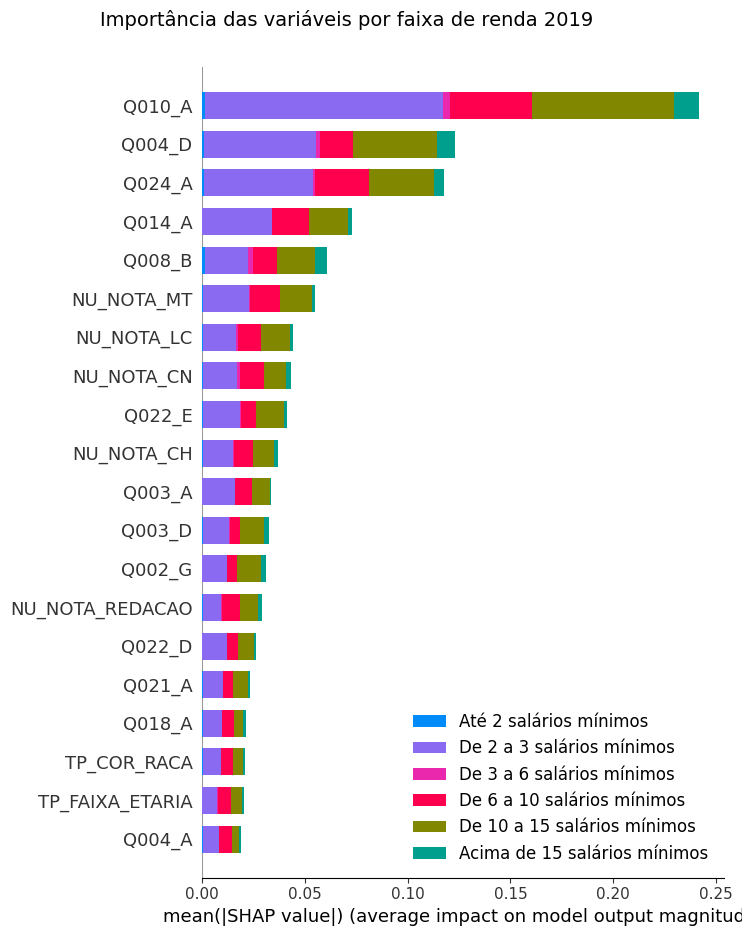

In [44]:
shap_multiclasses(df_transformado_rural, clf_rural, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


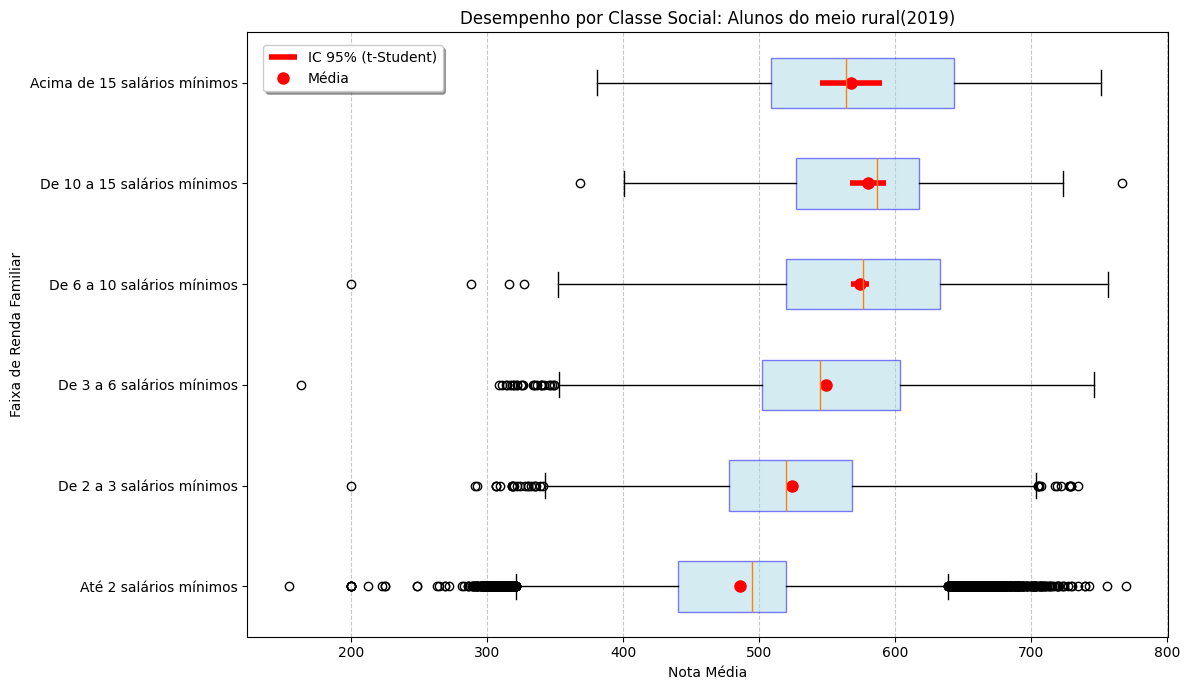

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,485.969789,494.520000,68.856324,33813,4741.193300,440.500000,519.979717,154.320000,769.96,615.640000,14.168849,485.235841,486.703738
3,De 2 a 3 salários mínimos,524.240422,519.979717,71.692227,2788,5139.775377,477.735000,568.685000,200.189533,734.38,534.190467,13.675448,521.578089,526.902756
4,De 3 a 6 salários mínimos,548.967313,544.750000,75.267603,4204,5665.212087,502.340000,603.360000,162.800000,746.26,583.460000,13.710762,546.691430,551.243196
5,De 6 a 10 salários mínimos,574.332565,576.840000,80.597764,557,6495.999588,519.979717,633.100000,200.189533,756.56,556.370467,14.033292,567.624613,581.040516
2,De 10 a 15 salários mínimos,580.114317,586.640000,73.309733,120,5374.316985,526.845000,617.520000,368.400000,766.68,398.280000,12.637118,566.863028,593.365605
0,Acima de 15 salários mínimos,567.620304,564.020000,86.407182,59,7466.201119,509.144767,643.320000,381.100000,751.66,370.560000,15.222708,545.102470,590.138138


In [16]:
analisar_desempenho_por_classe(dataset_rural, "Alunos do meio rural(2019)")

In [17]:
# Filtrar apenas homens do meio rural
dataset_rural_homem = dataset_rural[dataset_rural['TP_SEXO'] == "M"]
num_columns = dataset_rural_homem.shape[1]
num_rows = dataset_rural_homem.shape[0]
print(f"Número de colunas dataset rural homem: {num_columns}")
print(f"Número de linhas dataset rural homem: {num_rows}")

# Filtrar apenas mulheres do meio rural
dataset_rural_mulher = dataset_rural[dataset_rural['TP_SEXO'] == "F"]
num_columns = dataset_rural_mulher.shape[1]
num_rows = dataset_rural_mulher.shape[0]
print(f"Número de colunas dataset rural mulher: {num_columns}")
print(f"Número de linhas dataset rural mulher: {num_rows}")

Número de colunas dataset rural homem: 40
Número de linhas dataset rural homem: 17932
Número de colunas dataset rural mulher: 40
Número de linhas dataset rural mulher: 23609


In [47]:
modelo_rural_homem, clf_rural_homem, df_transformado_rural_homem = treinar_modelo(dataset_rural_homem)

Acurácia: 0.9999442337720277

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        35
      Até 2 salários mínimos       1.00      1.00      1.00     13978
 De 10 a 15 salários mínimos       1.00      1.00      1.00        60
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1356
   De 3 a 6 salários mínimos       1.00      1.00      1.00      2206
  De 6 a 10 salários mínimos       1.00      1.00      1.00       297

                    accuracy                           1.00     17932
                   macro avg       1.00      1.00      1.00     17932
                weighted avg       1.00      1.00      1.00     17932


Matriz de confusão:
 [[   35     0     0     0     0     0]
 [    0 13978     0     0     0     0]
 [    0     0    60     0     0     0]
 [    0     1     0  1355     0     0]
 [    0     0     0     0  2206     0]
 [    0     0     0  

Importância das features (agregada):
Feature Q010: 0.1629
Feature Q004: 0.0740
Feature NU_NOTA_CN: 0.0555
Feature NU_NOTA_CH: 0.0551
Feature NU_NOTA_MT: 0.0546
Feature NU_NOTA_LC: 0.0536
Feature Q001: 0.0485
Feature NU_NOTA_REDACAO: 0.0432
Feature Q002: 0.0424
Feature Q003: 0.0390
Feature Q024: 0.0384
Feature Q022: 0.0358
Feature Q008: 0.0258
Feature Q005: 0.0255
Feature TP_FAIXA_ETARIA: 0.0216
Feature Q011: 0.0206
Feature Q009: 0.0195
Feature Q019: 0.0193
Feature Q014: 0.0184
Feature Q013: 0.0173


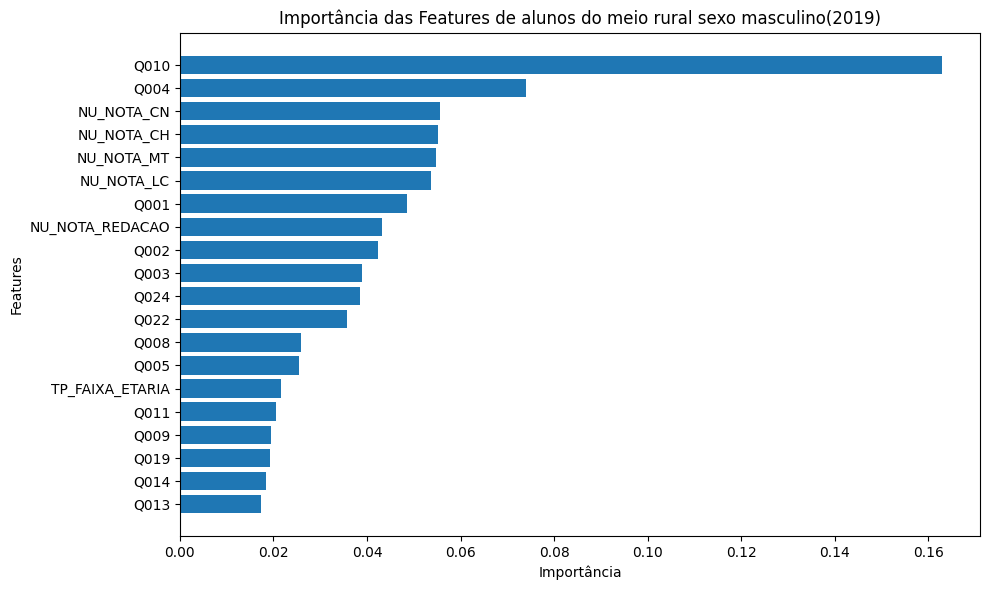

In [48]:
df_importancia_rural_homem = analisar_importancia_features_agregada(modelo_rural_homem,clf_rural_homem, "de alunos do meio rural sexo masculino(2019)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1509
NU_NOTA_CN: 0.0555
NU_NOTA_CH: 0.0551
NU_NOTA_MT: 0.0546
NU_NOTA_LC: 0.0536
Q004_D: 0.0509
NU_NOTA_REDACAO: 0.0432
Q024_A: 0.0275
Q005: 0.0255
TP_FAIXA_ETARIA: 0.0216
Q008_B: 0.0185
TP_COR_RACA: 0.0162
Q014_A: 0.0117
Q022_E: 0.0115
Q001_E: 0.0115
Q003_D: 0.0111
Q003_A: 0.0100
Q002_G: 0.0093
Q022_D: 0.0090
Q002_F: 0.0087


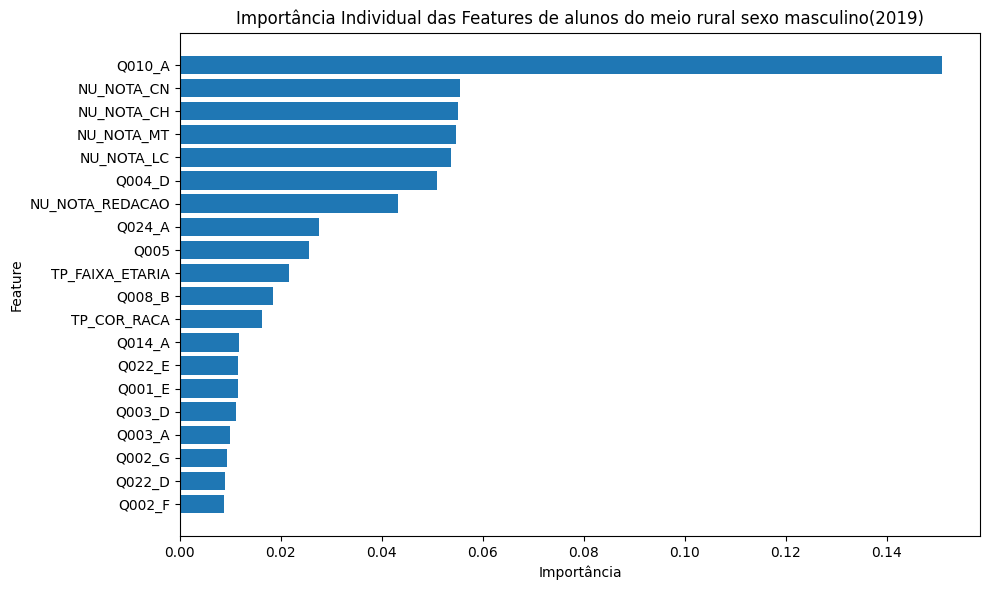

In [49]:
df_importancias_individuais_rural_homem = analisar_importancia_features(modelo_rural_homem, clf_rural_homem, "de alunos do meio rural sexo masculino(2019)", top_n=20)

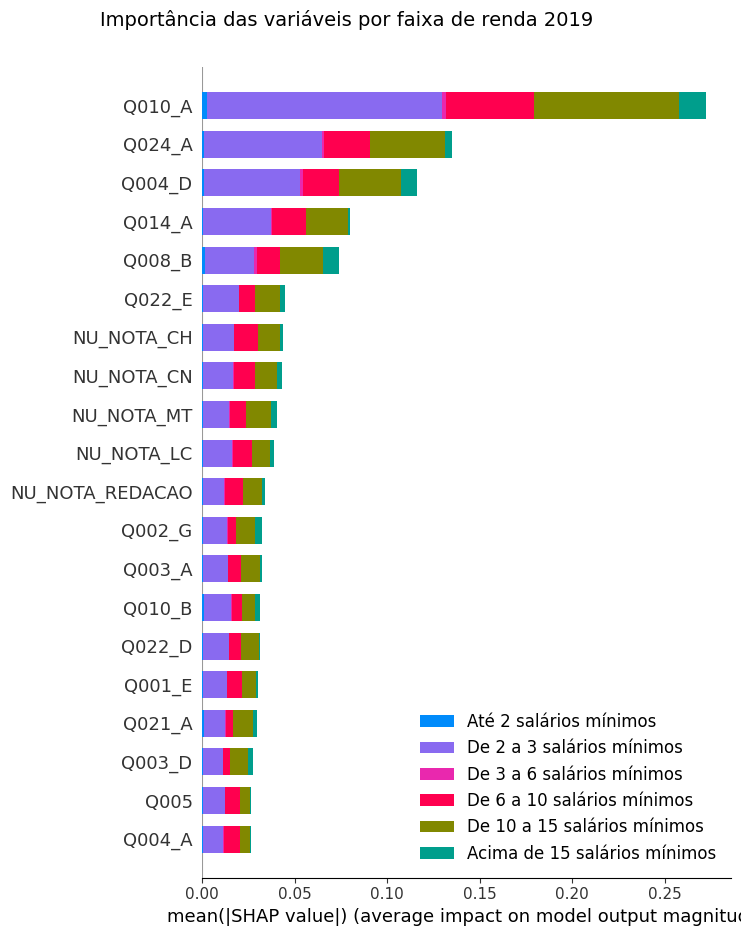

In [50]:
shap_multiclasses(df_transformado_rural_homem, clf_rural_homem, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


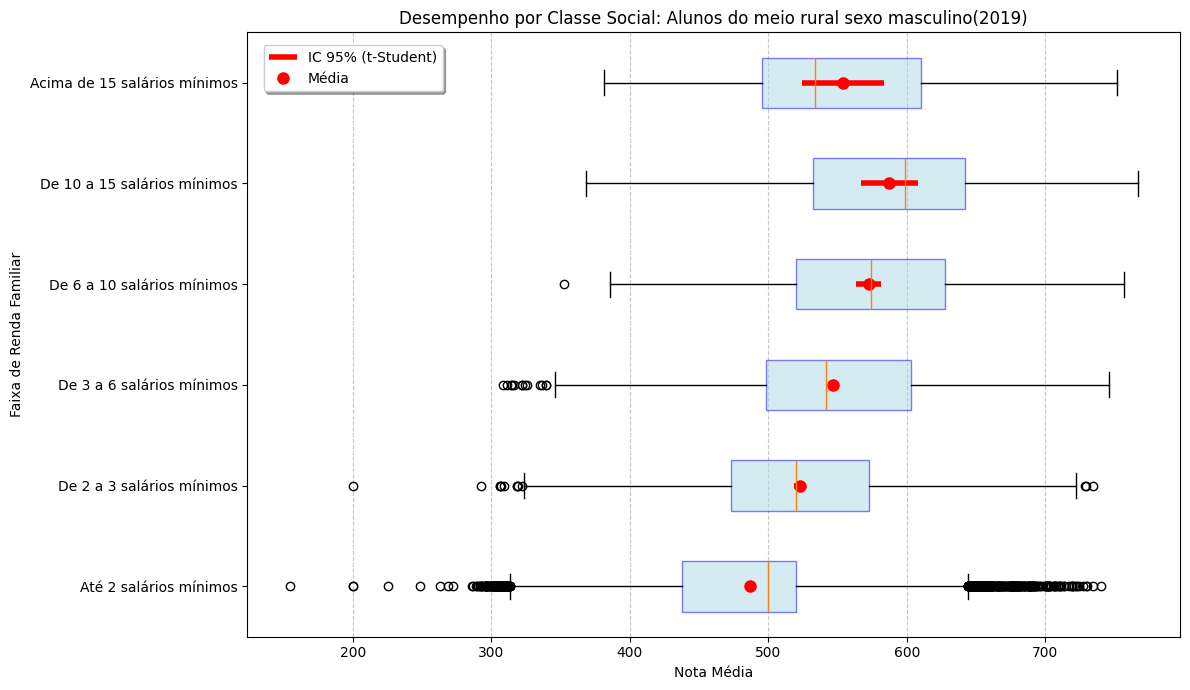

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,486.789219,499.950000,73.325279,13978,5376.596599,437.365000,519.979717,154.320000,739.94,585.620000,15.063045,485.573546,488.004893
3,De 2 a 3 salários mínimos,522.632271,519.979717,76.427847,1356,5841.215836,472.965000,572.630000,200.189533,734.38,534.190467,14.623637,518.560738,526.703804
4,De 3 a 6 salários mínimos,547.059438,541.920000,77.912927,2206,6070.424208,498.555000,603.375000,308.620000,746.26,437.640000,14.242132,543.806369,550.312508
5,De 6 a 10 salários mínimos,572.456040,573.800000,77.299166,297,5975.160996,519.979717,627.700000,352.469533,756.56,404.090467,13.503075,563.628818,581.283262
2,De 10 a 15 salários mínimos,587.352991,598.920000,80.338691,60,6454.305306,532.145000,642.335000,368.400000,766.68,398.280000,13.678093,566.599306,608.106675
0,Acima de 15 salários mínimos,554.021092,533.620000,86.915669,35,7554.333580,495.360000,610.040000,381.100000,751.66,370.560000,15.688152,524.164515,583.877669


In [18]:
analisar_desempenho_por_classe(dataset_rural_homem, "Alunos do meio rural sexo masculino(2019)")

In [52]:
modelo_rural_mulher, clf_rural_mulher, df_transformado_rural_mulher = treinar_modelo(dataset_rural_mulher)

Acurácia: 1.0

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        24
      Até 2 salários mínimos       1.00      1.00      1.00     19835
 De 10 a 15 salários mínimos       1.00      1.00      1.00        60
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1432
   De 3 a 6 salários mínimos       1.00      1.00      1.00      1998
  De 6 a 10 salários mínimos       1.00      1.00      1.00       260

                    accuracy                           1.00     23609
                   macro avg       1.00      1.00      1.00     23609
                weighted avg       1.00      1.00      1.00     23609


Matriz de confusão:
 [[   24     0     0     0     0     0]
 [    0 19835     0     0     0     0]
 [    0     0    60     0     0     0]
 [    0     0     0  1432     0     0]
 [    0     0     0     0  1998     0]
 [    0     0     0     0     0   26

In [ ]:
df_importancia_rural_mulher = analisar_importancia_features_agregada(modelo_rural_mulher,clf_rural_mulher, "de alunos do meio rural sexo feminino(2019)", top_n=20)

NameError: name 'modelo_rural_mulher' is not defined

Importância das features (sem agregação):
Q010_A: 0.1337
NU_NOTA_MT: 0.0758
NU_NOTA_CN: 0.0715
NU_NOTA_LC: 0.0687
NU_NOTA_CH: 0.0624
Q004_D: 0.0586
NU_NOTA_REDACAO: 0.0454
Q024_A: 0.0313
Q005: 0.0269
TP_COR_RACA: 0.0179
Q008_B: 0.0166
TP_FAIXA_ETARIA: 0.0160
Q022_E: 0.0133
Q003_A: 0.0103
Q014_A: 0.0100
Q009_D: 0.0097
Q003_D: 0.0094
Q022_D: 0.0086
Q018_B: 0.0081
Q002_G: 0.0076


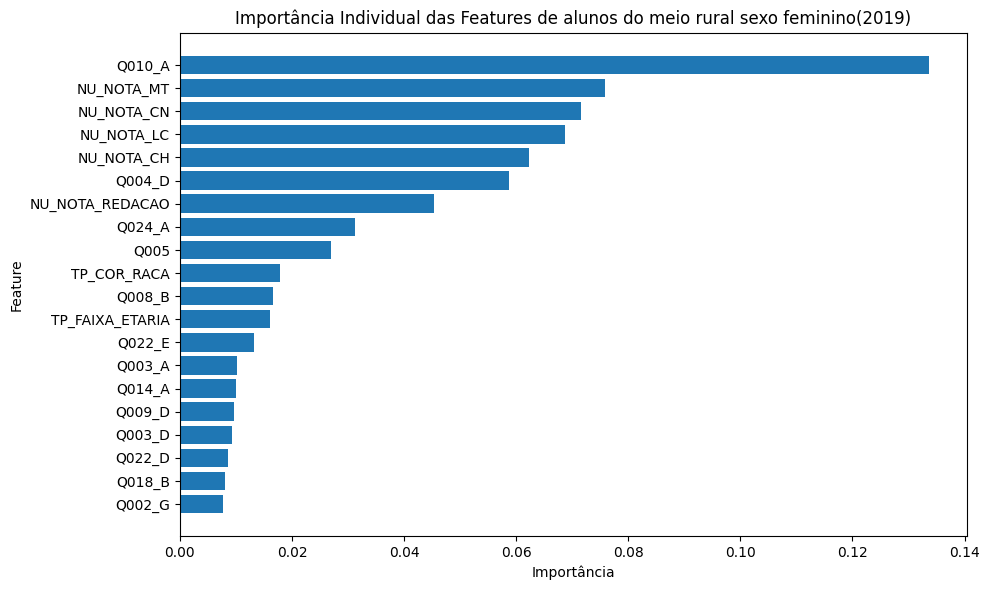

In [54]:
df_importancias_individuais_rural_mulher = analisar_importancia_features(modelo_rural_mulher, clf_rural_mulher, "de alunos do meio rural sexo feminino(2019)", top_n=20)

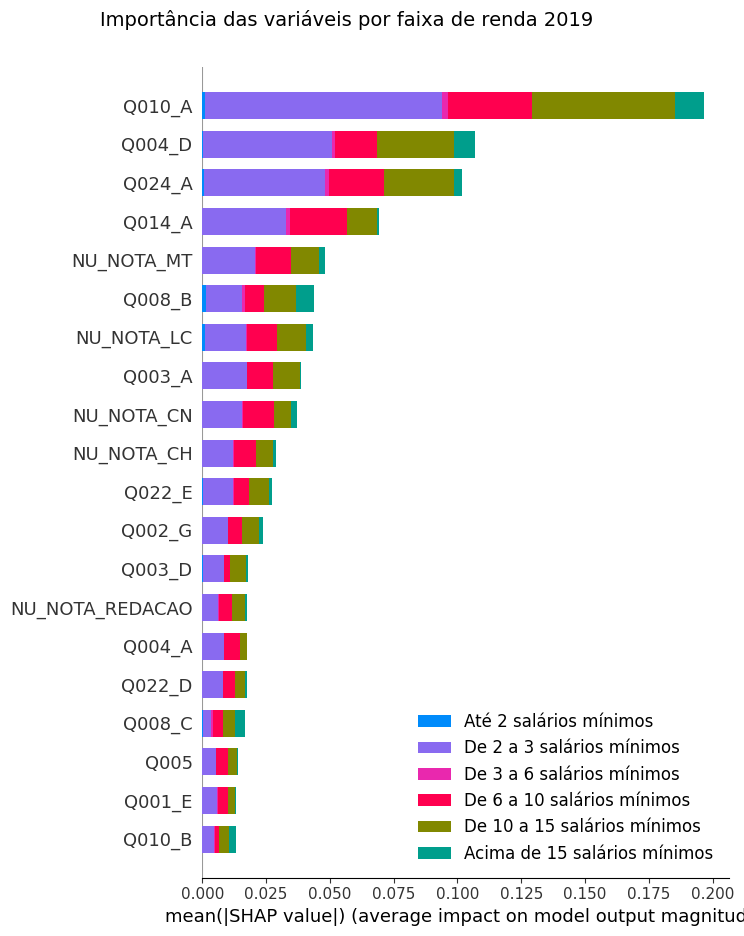

In [55]:
shap_multiclasses(df_transformado_rural_mulher, clf_rural_mulher, "2019")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_14504\450741212.py:211: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


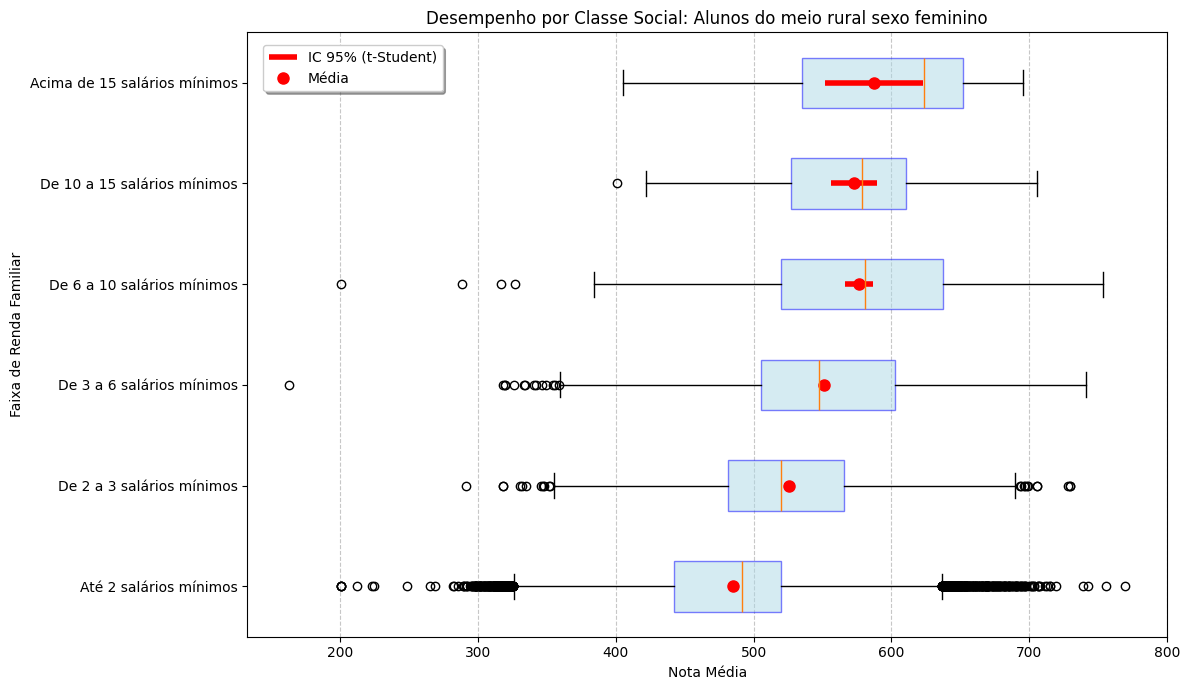

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ic_inf,ic_sup
1,Até 2 salários mínimos,485.392326,491.500000,65.519902,19835,4292.857577,442.290000,519.979717,200.189533,769.96,569.770467,13.498339,484.480458,486.304193
3,De 2 a 3 salários mínimos,525.763225,519.979717,66.891022,1432,4474.408798,481.395000,565.740000,291.160000,729.86,438.700000,12.722651,522.295762,529.230689
4,De 3 a 6 salários mínimos,551.073805,547.440000,72.195367,1998,5212.170990,505.400000,602.890000,162.800000,741.06,578.260000,13.100853,547.906259,554.241352
5,De 6 a 10 salários mínimos,576.476134,580.900000,84.307023,260,7107.674152,519.979717,637.775000,200.189533,753.50,553.310467,14.624547,566.180352,586.771915
2,De 10 a 15 salários mínimos,572.875643,578.600000,65.412887,60,4278.845770,526.845000,610.555000,400.780000,705.54,304.760000,11.418340,555.977703,589.773584
0,Acima de 15 salários mínimos,587.452488,623.670000,83.478688,24,6968.691326,535.489929,651.720000,405.240000,695.54,290.300000,14.210288,552.202530,622.702447


In [20]:
analisar_desempenho_por_classe(dataset_rural_mulher, "Alunos do meio rural sexo feminino")